In [1]:
import sys
import os

import xarray as xr
import rioxarray
import sys
sys.path.insert(1, '../Tools/')
import argparse 
import os
import sys
import xarray as xr
import mypythonlib
from mypythonlib import myfunctions 
import geopandas as gpd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.ticker import MaxNLocator, FuncFormatter
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import shape, MultiPolygon, box
from affine import Affine
import rasterio
from shapely import wkt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from matplotlib.colors import LinearSegmentedColormap

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib import cm
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import xarray as xr
from shapely.geometry import mapping, shape, MultiPolygon, box, Point
from affine import Affine
import rasterio
from shapely import wkt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import os
import warnings

In [2]:
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#FFBA08', # tab:yellow
    'bark_beetle': '#714709'  # tab:brown
}

In [3]:
def calculate_area(gdf):
    """Calculate area in square meters and square kilometers for a GeoDataFrame."""
    # Set the coordinate reference system (CRS) for the GeoDataFrame to WGS84
    gdf.crs = 'EPSG:4326'
    
    # Calculate the area in degrees (not used for final calculation, but keeping it here if needed for other purposes)
    #gdf['area_degrees'] = gdf.geometry.area
    
    # Define the target projection system (e.g., UTM Zone 18N)
    target_crs = 'EPSG:32618'
    
    # Reproject the GeoDataFrame to the target projection system
    gdf_projected = gdf.to_crs(target_crs)
    
    # Calculate the area in square meters
    print("     Calculating area in square meters...")
    gdf_projected['area_meters'] = gdf_projected.geometry.area
    
    # Assign the calculated area back to the original GeoDataFrame
    gdf['area_meters'] = gdf_projected['area_meters']
    # Convert square meters to square kilometers
    gdf['square_km'] = gdf['area_meters'] / 1e6
    # Print step information
    print("     Converting area from square meters to square kilometers...")
    
    # Return the GeoDataFrame with the new area columns
    return gdf

# Analysis of IDS / REFDM

In [13]:
# Define the path to your shapefile
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"

# Load the shapefile using geopandas
refdm_dataset = gpd.read_file(refdm_path)

# Optionally, display the CRS (Coordinate Reference System)
print("CRS:", refdm_dataset.crs)

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [14]:
print(f"Size of refdm_dataset: {len(refdm_dataset)}")

# Dissolve the dataset by the USDA_IDX column
refdm_dissolved = refdm_dataset.dissolve(by='USDA_IDX')

print(f"Size of unique refdm_dataset events : {len(refdm_dissolved)}")

# Optionally, reset the index if needed
refdm_dissolved.reset_index(inplace=True)
refdm_dissolved.head()

Size of refdm_dataset: 17894


Size of unique refdm_dataset events : 7865


,USDA_IDX,geometry,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,cluster_id,area_km2
0,bark_beetle_2017_0,"MULTIPOLYGON (((-86.10070 32.13939, -86.10050 ...",2017,E093N027T3,0,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14245,0.455326
1,bark_beetle_2017_1,"MULTIPOLYGON (((-86.02044 32.00757, -86.02006 ...",2017,E093N027T3,1,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14246,0.070908
2,bark_beetle_2017_10,"MULTIPOLYGON (((-86.99148 32.66153, -86.99129 ...",2017,E090N027T3,10,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,14253,0.043116
3,bark_beetle_2017_100,"MULTIPOLYGON (((-87.11647 32.88050, -87.11667 ...",2017,E090N027T3,100,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,6193,0.018841
4,bark_beetle_2017_1000,"MULTIPOLYGON (((-88.93998 34.02285, -88.94017 ...",2017,E090N027T3,1000,bark_beetle,2017,8,Mortality,2,11003,1,No Data,None,-1,10795,0.107244


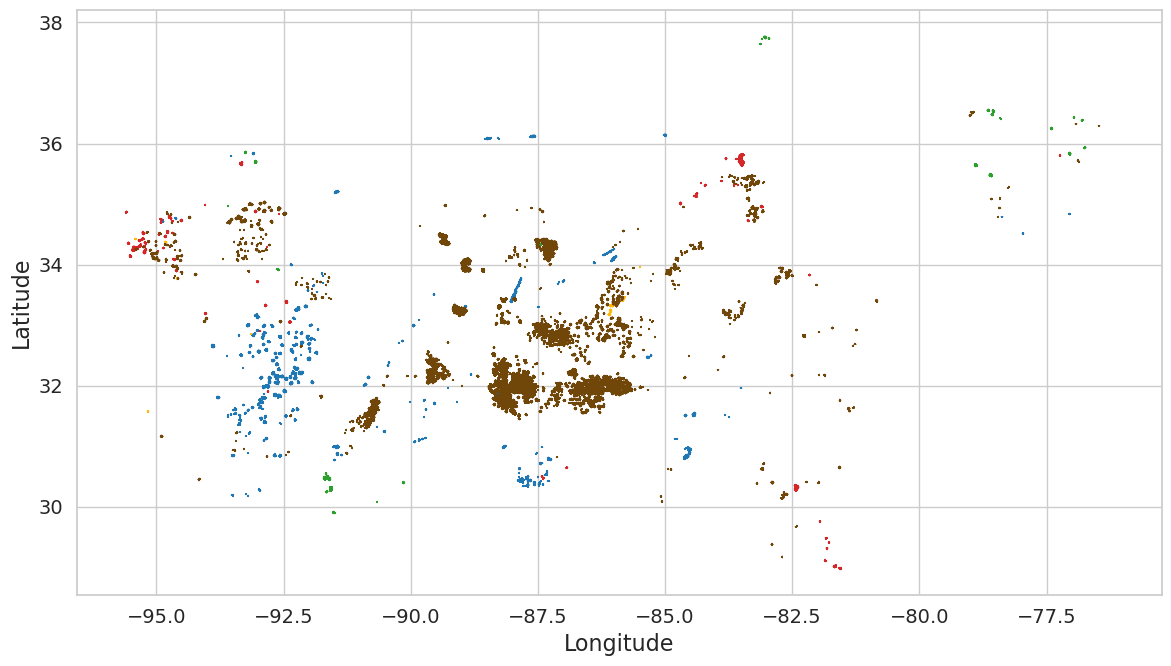

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

refdm_dissolved['color'] = refdm_dissolved['DCA_ID'].map(custom_colors)
# Plot each disturbance type with its corresponding color
for disturbance, color in custom_colors.items():
    refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
        ax=ax, linewidth=1.5, color=color, edgecolor=color  # Adjust linewidth and edgecolor as needed
    )

# Customize the plot
#ax.set_title('Radar Enhanced Forest Disturbance Mapping Events', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(True)

In [16]:
# Define file path
usa_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp"
usa = gpd.read_file(usa_path)

# List of regions to filter mainland parts
regions_to_clean = ['05', '10']

def get_mainland(geodataframe):
    """
    Get the mainland part of a GeoDataFrame by keeping only the largest area polygon.
    """
    exploded = geodataframe.explode(index_parts=True)
    exploded['area'] = exploded.area
    mainland_part = exploded.loc[exploded['area'].idxmax()]
    return exploded[exploded.area == mainland_part['area']]

# Filter mainland parts for specified regions
cleaned_parts = []
for region in regions_to_clean:
    region_gdf = usa[usa['REGION'] == region]
    cleaned_region = get_mainland(region_gdf)
    cleaned_parts.append(cleaned_region)

# Combine cleaned parts into one GeoDataFrame
cleaned_parts_gdf = gpd.GeoDataFrame(pd.concat(cleaned_parts, ignore_index=True))

# Remove original regions to clean from the usa dataset and append the cleaned parts
usa_mainland = usa[~usa['REGION'].isin(regions_to_clean)]
usa_mainland = usa_mainland.append(cleaned_parts_gdf, ignore_index=True)


def get_region_8(path):

    usa = gpd.read_file(path)
    # Filter for REGION 08
    region_8 = usa[usa['REGION'] == '08']

    # Print to verify
    r8 = region_8.explode(index_parts=True)
    r8.reset_index()
    r8 = r8[0:1]

    return r8

r8 = get_region_8(usa_path)

/tmp/ipykernel_3108182/1381847324.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_3108182/1381847324.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  return exploded[exploded.area == mainland_part['area']]
/tmp/ipykernel_3108182/1381847324.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  exploded['area'] = exploded.area
/tmp/ipykernel_3108182/1381847324.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before t

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
def plot_figure_1(usa_mainland, r8, refdm_dissolved, save_dir):

    # Set Seaborn style
    sns.set(style="whitegrid")

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Plot the entire USA in grey in the upper left corner
    sub_ax = fig.add_axes([0, 0.7, 0.3, 0.3])  # [left, bottom, width, height]
    #usa.boundary.plot(ax=sub_ax, color='grey')
    # Plot other regions in grey
    usa_mainland[usa_mainland['REGION'] != '08'].plot(ax=sub_ax, color='grey', edgecolor='grey')

    # Plot Region 8 in black
    usa_mainland[usa_mainland['REGION'] == '08'].plot(ax=sub_ax, color='black', edgecolor='black')

    # Customize the plot
    #sub_ax.set_title('Study Area', fontsize=20)
    sub_ax.set_xlabel('Longitude', fontsize=16)
    sub_ax.set_ylabel('Latitude', fontsize=16)
    sub_ax.tick_params(axis='both', which='major', labelsize=14)
    sub_ax.grid(True)
    sub_ax.axis('on')

    # Plot Region 8 in the main part of the image
    # Map colors to DCA_IDs
    refdm_dissolved['color'] = refdm_dissolved['DCA_ID'].map(custom_colors)

    # Plot the region outline
    r8.boundary.plot(ax=ax, linewidth=2, color='black')

    # Plot each disturbance type with its corresponding color
    for disturbance, color in custom_colors.items():
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=1.5, color=color, edgecolor=color  # Adjust linewidth and edgecolor as needed
        )

    # Customize the plot
    #ax.set_title('Radar Enhanced Forest Disturbance Mapping Events', fontsize=20)
    ax.set_xlabel('Longitude', fontsize=16)
    ax.set_ylabel('Latitude', fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True)

    # Create custom legend on the left side
    # legend_patches = [mpatches.Patch(color=color, label=disturbance) for disturbance, color in custom_colors.items()]
    # ax.legend(handles=legend_patches, fontsize=14, title="Disturbance Type", title_fontsize=16, loc='center left')
    legend_patches = [mpatches.Patch(color=color, label=disturbance) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=14, title="Disturbance Type", title_fontsize=16, loc='center left', facecolor='white', framealpha=1)

    ax.axis('off')

    # Add title
    #plt.title('Region 8 Highlighted within USA Map', fontsize=16)
    plt.tight_layout()
    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'figure_1_output.png'), bbox_inches='tight')
    # Show plot
    plt.show()


/tmp/ipykernel_834167/3092914512.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


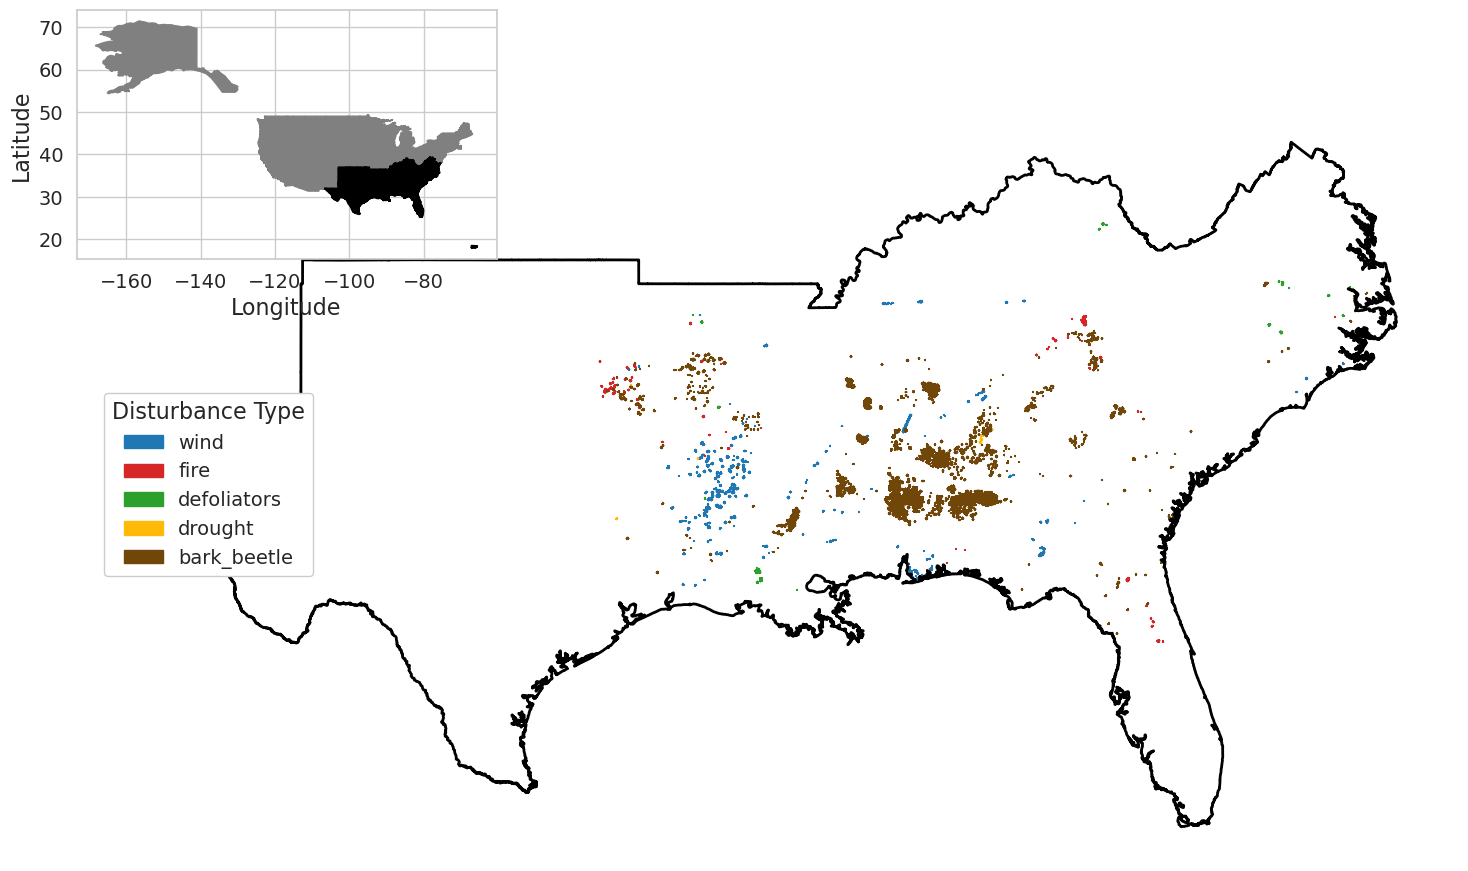

In [11]:
plot_figure_1(usa_mainland, r8, refdm_dissolved, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/")

# Plotting Data

In [9]:
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')
gdf_ids = gdf.rename(columns={'index_usda': 'USDA_IDX'})
print(f"Elements in the Dataframe: {len(gdf_ids)}")
gdf_ids.head(5)
gdf= gdf_ids

Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Elements in the Dataframe: 9215


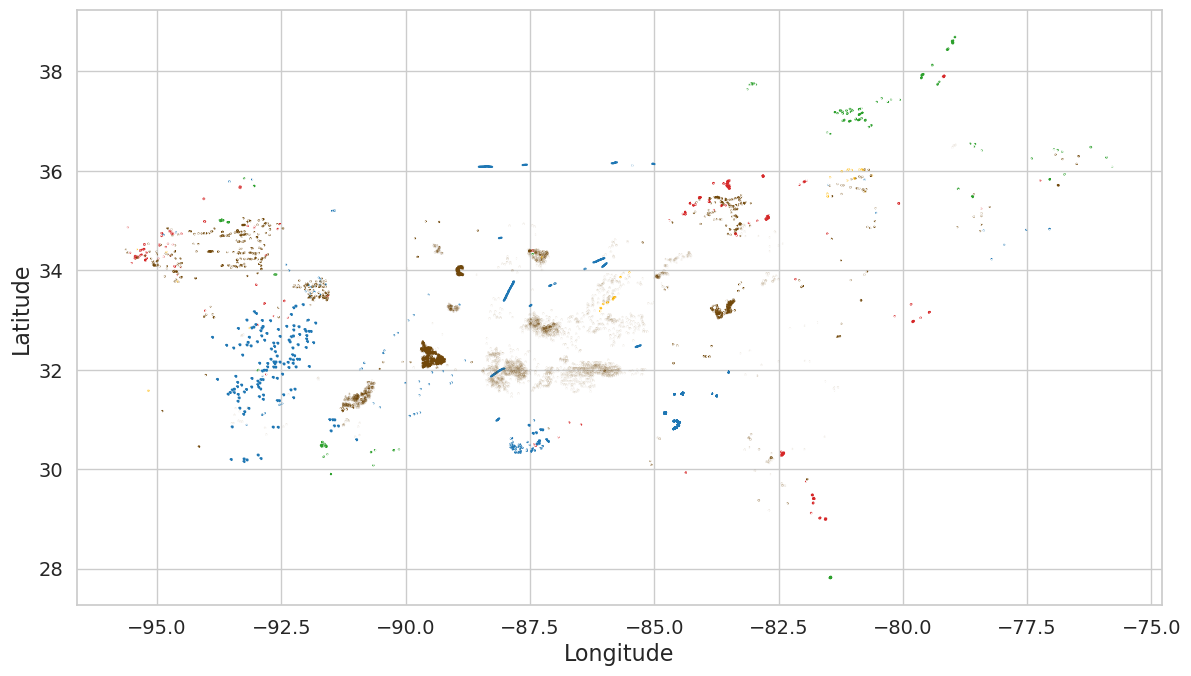

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

gdf_ids['color'] = gdf_ids['DCA_ID'].map(custom_colors)
# Plot each disturbance type with its corresponding color
for disturbance, color in custom_colors.items():
    gdf_ids[gdf_ids['DCA_ID'] == disturbance].plot(
        ax=ax, linewidth=1.5, color=color, edgecolor=color  # Adjust linewidth and edgecolor as needed
    )

# Customize the plot
#ax.set_title('Radar Enhanced Forest Disturbance Mapping Events', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(True)

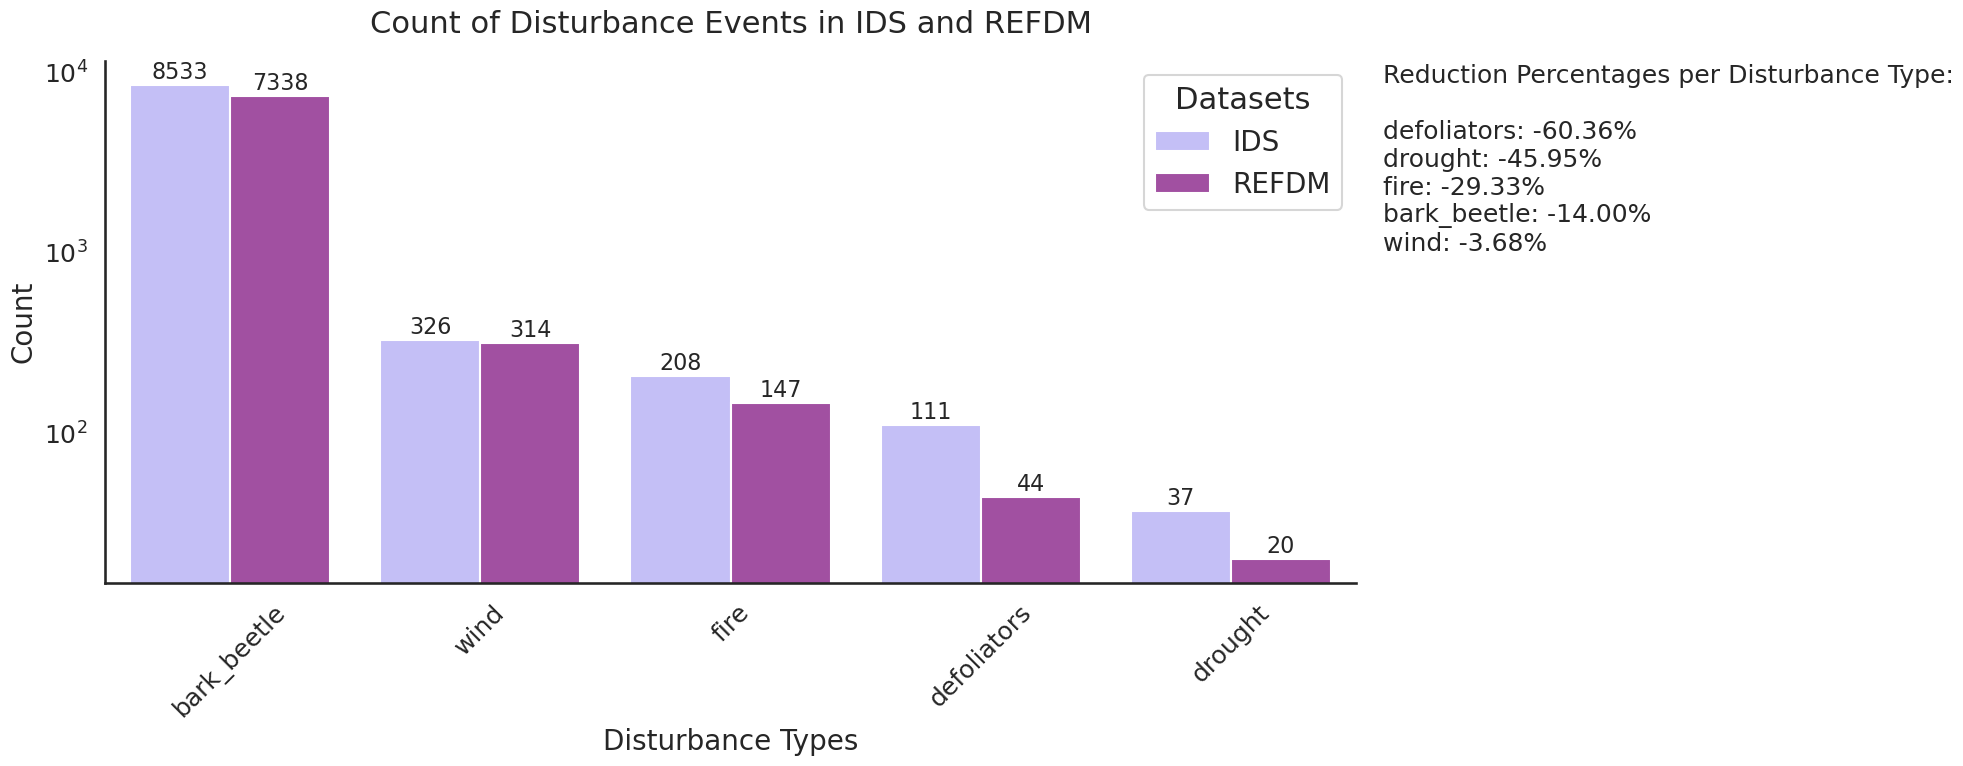

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by DCA_ID and count occurrences for both datasets
dca_counts_refdm = refdm_dissolved['DCA_ID'].value_counts()
dca_counts_ids = gdf['DCA_ID'].value_counts()

# Combine the counts into a single DataFrame
counts_df = pd.DataFrame({
    'IDS': dca_counts_ids,
    'REFDM': dca_counts_refdm
}).fillna(0)  # Fill NaN with 0 for counts that are missing in either dataset

# Reset index to turn DCA_ID into a column
counts_df.reset_index(inplace=True)
counts_df.rename(columns={'index': 'DCA_ID'}, inplace=True)

# Calculate reduction percentage
counts_df['Reduction (%)'] =  - 100 * (counts_df['IDS'] - counts_df['REFDM']) / counts_df['IDS']

# Sort the DataFrame by 'Reduction (%)' in ascending order
counts_df_sorted = counts_df.sort_values(by='Reduction (%)')

# Format the reduction percentages into a string for display
reduction_text = "Reduction Percentages per Disturbance Type:\n\n"
for index, row in counts_df_sorted.iterrows():
    reduction_text += f"{row['DCA_ID']}: {row['Reduction (%)']:.2f}%\n"

# Drop the 'Reduction (%)' column from counts_df if it exists
if 'Reduction (%)' in counts_df.columns:
    counts_df.drop(columns=['Reduction (%)'], inplace=True)

# Melt the DataFrame for easier plotting with Seaborn
counts_melted = counts_df.melt(id_vars='DCA_ID', var_name='Dataset', value_name='Count')


# Set the style and color palette
sns.set(style="white", context="talk")

# Define the custom color palette with bold shades of blue and orange
#palette = sns.color_palette(["#C5D86D", "#F96900"])  # Bold blue and bold orange
#palette = sns.color_palette(["#12A5A3", "#CA0266"])  # teal and rose 
palette = sns.color_palette(["#BCB6FF", "#AF42AE"]) #Periwinkel and purpureus "#B3001B"]) 
#palette = sns.color_palette(["#E09540", "#87D3F8"]) #Butterscotch and Pale azure
# Create the bar plot
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=counts_melted, x='DCA_ID', y='Count', hue='Dataset', palette=palette)

# Add numbers over the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=16)

# Customize the plot
plt.xlabel('Disturbance Types', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.title('Count of Disturbance Events in IDS and REFDM', fontsize=22, pad=20)  # Adjust title position
plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=18)
plt.yscale('log')  # Set y-axis to log scale
plt.legend(title='Datasets', title_fontsize=22, fontsize=20)
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine
plt.gca().yaxis.grid(False)  # Remove y-axis gridlines
plt.tight_layout()

# Add reduction percentages as a text box
plt.gcf().text(1, 0.63, reduction_text, fontsize=18, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

In [22]:
def plot_radar_reduction_potential(refdm_gdf, ids_gdf, save_dir):

    dca_counts_refdm = refdm_gdf['DCA_ID'].value_counts()
    dca_counts_ids = ids_gdf['DCA_ID'].value_counts()

    # Combine the counts into a single DataFrame
    counts_df = pd.DataFrame({
        'IDS': dca_counts_ids,
        'REFDM': dca_counts_refdm
    }).fillna(0)  # Fill NaN with 0 for counts that are missing in either dataset

    # Reset index to turn DCA_ID into a column
    counts_df.reset_index(inplace=True)
    counts_df.rename(columns={'index': 'DCA_ID'}, inplace=True)
    # Calculate reduction percentage
    counts_df['Reduction (%)'] =  - 100 * (counts_df['IDS'] - counts_df['REFDM']) / counts_df['IDS']

    # Ensure the DCA_ID is in the specified order
    counts_df['DCA_ID'] = pd.Categorical(counts_df['DCA_ID'], categories=['bark_beetle', 'wind', 'fire', 'defoliators', 'drought'], ordered=True)
    counts_df_sorted = counts_df.sort_values('DCA_ID')

    # Create a figure with 2 rows and 1 column for the two subplots
    fig = plt.figure(figsize=(22, 10))
    gs = GridSpec(nrows=2, ncols=1, height_ratios=[3, 1])  # Define height ratios

    # Plot Counts in the first subplot
    ax1 = fig.add_subplot(gs[0])
    bar_width = 0.35  # Width of the bars
    bar_positions = range(len(counts_df_sorted))  # X positions for bars

    ax1.bar(bar_positions, counts_df_sorted['IDS'], width=bar_width, color="#BCB6FF", label='IDS')
    ax1.bar([pos + bar_width for pos in bar_positions], counts_df_sorted['REFDM'], width=bar_width, color="#AF42AE", label='REFDM')

    # Add annotations for counts above bars
    for i, (count_ids, count_refdm) in enumerate(zip(counts_df_sorted['IDS'], counts_df_sorted['REFDM'])):
        ax1.text(bar_positions[i], count_ids + 2, str(int(count_ids)), ha='center', va='bottom', color='black', fontsize=16)
        ax1.text(bar_positions[i] + bar_width, count_refdm + 2, str(int(count_refdm)), ha='center', va='bottom', color='black', fontsize=16)

    # Set labels and title for the first subplot
    ax1.set_ylabel('Amount of Disturbance Events', fontsize=20)  # Increase font size for ylabel
    ax1.set_title('Radar Detection Potential per Disturbance Type', fontsize=24)  # Increase font size for title
    ax1.set_yscale('log')
    #ax1.legend(fontsize=20, title='Datasets')
    legend = ax1.legend(fontsize=20, title='Datasets')  # Increase font size for legend and add title
    legend.get_title().set_fontsize('24')
    ax1.grid(False)
    plt.yticks(fontsize=16)
    plt.xticks(bar_positions, counts_df_sorted['DCA_ID'], fontsize=18)

    # Plot Reduction (%) in the second subplot with negative y-axis

    double_bar_width = bar_width * 2  # Make the bottom bars as wide as the combined width of the top two bars
    bar_offset = 0.2  # Offset to move the lower bars to the right
    # Rotate x-axis labels for ax2 and apply a small offset
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.bar([pos + bar_offset for pos in bar_positions], counts_df_sorted['Reduction (%)'], width=double_bar_width, color='#FF3E41', label='Reduction (%)')


    # Add annotations for reduction below bars
    for i, reduction_percentage in enumerate(counts_df_sorted['Reduction (%)']):
        ax2.text(bar_positions[i] + bar_offset, reduction_percentage - 2, f'{reduction_percentage:.2f}%', ha='center', va='top', color='black', fontsize=16)

    # Set labels and title for the second subplot
    ax2.set_xlabel('Disturbance Type', fontsize=20)  # Increase font size for xlabel
    ax2.set_ylim(0, -75)
    ax2.invert_yaxis()
    ax2.set_ylabel('Reduction \nPercentage \n(%)', fontsize=20)  # Increase font size for ylabel
    plt.xticks([pos + 0.2 for pos in bar_positions], counts_df_sorted['DCA_ID'], fontsize=18, ha='right')  # Adjust the rotation and alignment

    # Rotate x-axis labels for ax2
    ax2.set_xticklabels(counts_df_sorted['DCA_ID'], ha='right', fontsize=0)  # Rotate and increase font size
    ax2.grid(False)

    # Adjust x-axis ticks and labels
    plt.yticks(fontsize=16)
    plt.tight_layout()  # Ensures labels, titles, and legends do not overlap
    
    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'ids_refdm_radar_reduction_potential.png'), bbox_inches='tight')

    plt.show()

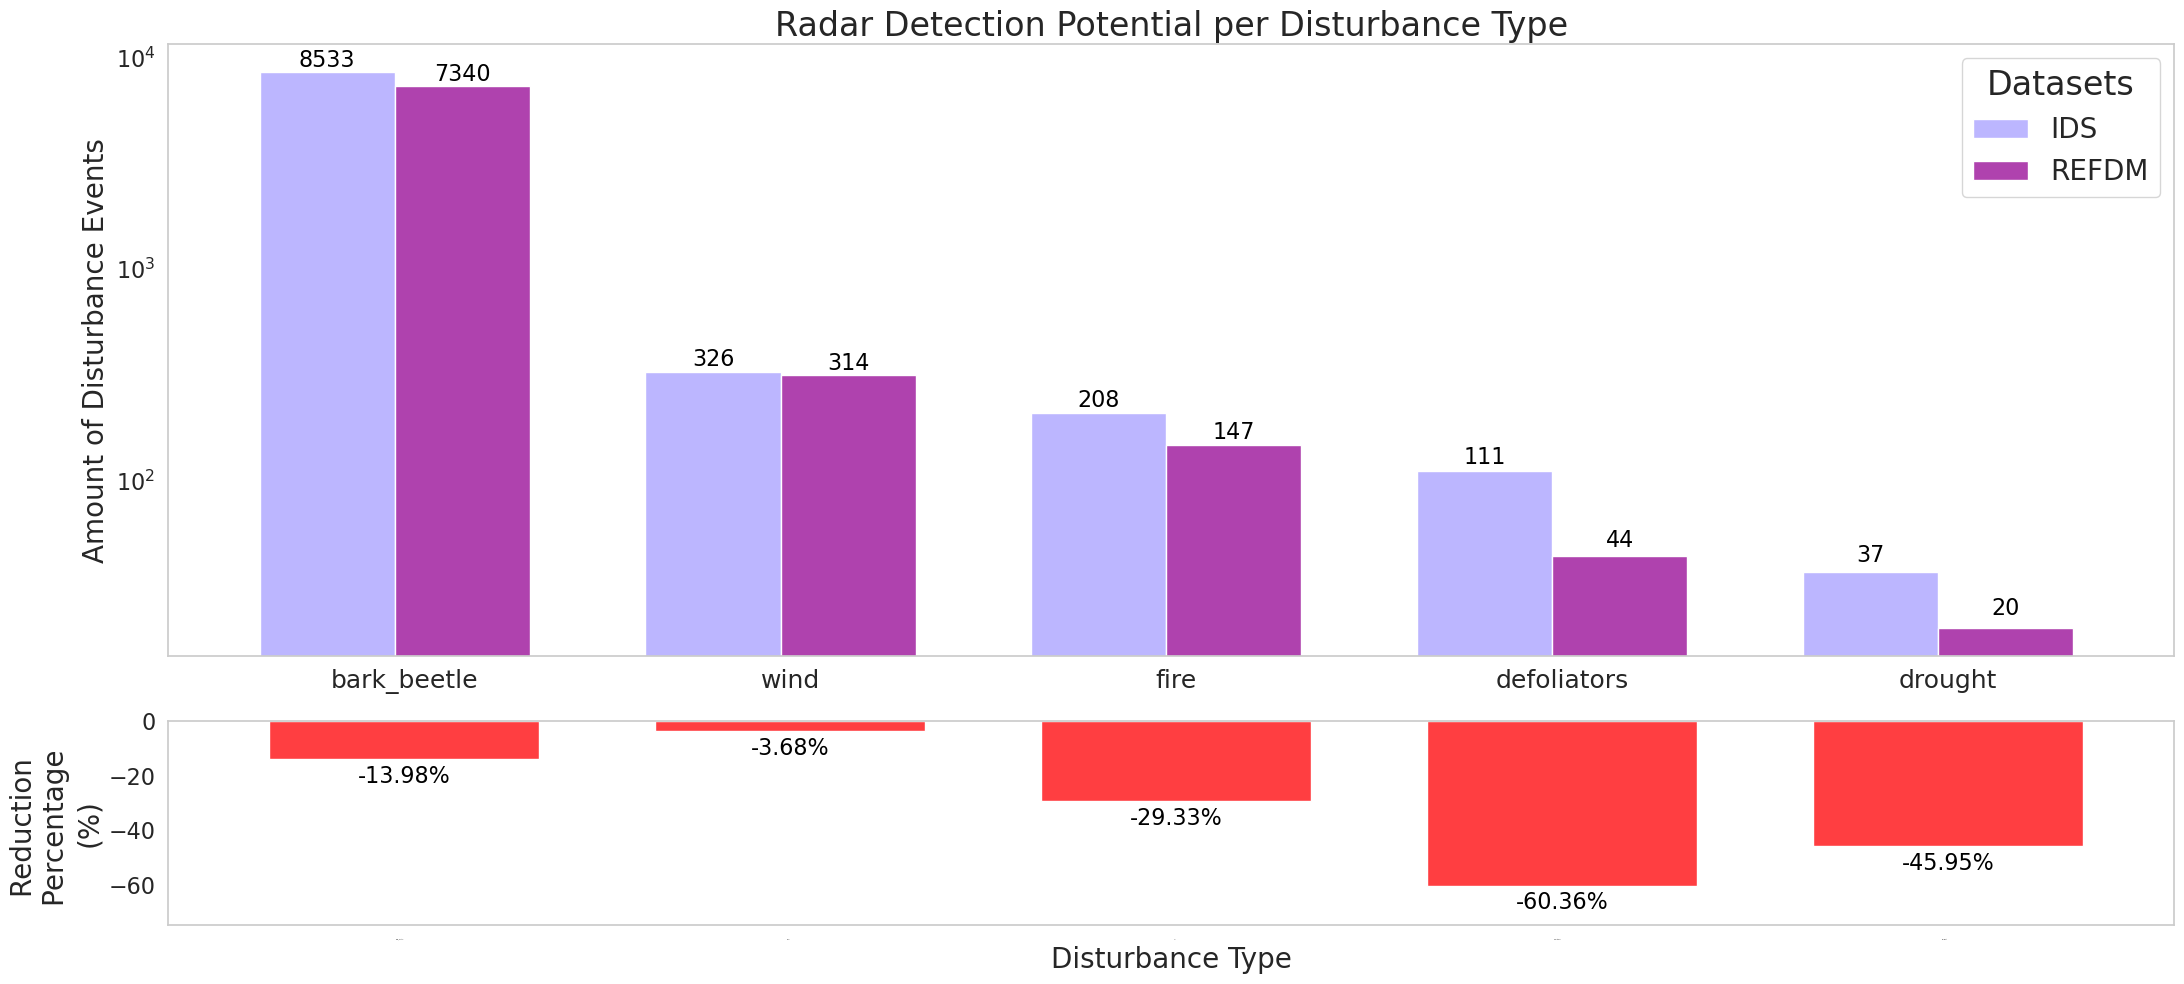

In [24]:
plot_radar_reduction_potential(refdm_dissolved, gdf_ids, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/")

In [30]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

def calculate_size_shift_difference(ids_gdf, refdm_gdf_dissolved):
    """
    Calculate centroid shift and size difference between polygons in two GeoDataFrames based on USDA_IDX.

    Parameters:
    - ids_gdf (GeoDataFrame): GeoDataFrame containing polygons with USDA_IDX and geometry.
    - refdm_gdf_dissolved (GeoDataFrame): GeoDataFrame containing reference polygons with USDA_IDX and geometry.

    Returns:
    - result_gdf (GeoDataFrame): GeoDataFrame containing USDA_IDX, centroid_shift, size_difference, and geometry.
    """

    # Calculate centroids for each polygon in both GeoDataFrames
    ids_gdf['centroid'] = ids_gdf.geometry.centroid
    refdm_gdf_dissolved['centroid'] = refdm_gdf_dissolved.geometry.centroid

    # Initialize lists to hold the results
    usda_idx_list = []
    centroid_shift_list = []
    size_difference_list = []

    # Iterate through unique USDA_IDX values in ids_gdf
    unique_usda_idx = ids_gdf['USDA_IDX'].unique()

    for usda_idx in unique_usda_idx:
        # Get the corresponding rows in both GeoDataFrames for the current USDA_IDX
        gdf_row = ids_gdf[ids_gdf['USDA_IDX'] == usda_idx]
        refdm_row = refdm_gdf_dissolved[refdm_gdf_dissolved['USDA_IDX'] == usda_idx]
        
        # Check if both rows exist (they should exist if data is correctly structured)
        if not gdf_row.empty and not refdm_row.empty:
            # Calculate the centroid shift between centroids of the two polygons
            centroid_shift = gdf_row.iloc[0]['centroid'].distance(refdm_row.iloc[0]['centroid'])
            
            # Calculate the size difference between areas of the two polygons
            size_difference = gdf_row.iloc[0]['geometry'].area - refdm_row.iloc[0]['geometry'].area
            
            # Append the results to the lists
            usda_idx_list.append(usda_idx)
            centroid_shift_list.append(centroid_shift)
            size_difference_list.append(size_difference)

    # Create a DataFrame from the results
    results_df = pd.DataFrame({
        'USDA_IDX': usda_idx_list,
        'centroid_shift': centroid_shift_list,
        'size_difference': size_difference_list
    })

    # Merge with original gdf to get geometry
    result_gdf = ids_gdf.merge(results_df, on='USDA_IDX')

    # Convert to GeoDataFrame with original geometry and CRS
    result_gdf = gpd.GeoDataFrame(result_gdf, geometry='geometry', crs=ids_gdf.crs)

    return result_gdf


In [31]:
result_gdf = calculate_size_shift_difference(gdf_ids, refdm_dissolved)
result_gdf

/tmp/ipykernel_1729525/3269999834.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  refdm_gdf_dissolved['centroid'] = refdm_gdf_dissolved.geometry.centroid


,USDA_IDX,DCA_ID,SURVEY_YEAR,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,geometry,area_km2,centroid,centroid_shift,size_difference
0,bark_beetle_2017_0,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,"POLYGON ((-86.09680 32.14270, -86.09685 32.142...",0.005641,POINT (-86.09683 32.14302),0.002713,-0.000037
1,bark_beetle_2017_1,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,"POLYGON ((-86.01648 32.01100, -86.01655 32.011...",0.011262,POINT (-86.01652 32.01146),0.000449,-0.000044
2,bark_beetle_2017_2,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,"POLYGON ((-86.24623 32.06300, -86.24629 32.063...",0.011274,POINT (-86.24626 32.06345),0.001195,-0.000040
3,bark_beetle_2017_3,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,"POLYGON ((-86.08565 32.05823, -86.08572 32.058...",0.011273,POINT (-86.08568 32.05869),0.003811,-0.000036
4,bark_beetle_2017_4,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,"POLYGON ((-87.40289 32.86707, -87.40294 32.867...",0.005732,POINT (-87.40291 32.86740),0.001695,-0.000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7858,wind_2020_9222,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),NaN,NaN,19838,"POLYGON ((-88.36541 36.09120, -88.26354 36.080...",7.410090,POINT (-88.39592 36.08460),0.050876,0.000386
7859,wind_2020_9223,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19839,"POLYGON ((-85.81513 36.15473, -85.84284 36.152...",1.494372,POINT (-85.80399 36.16108),0.033999,0.000097
7860,wind_2020_9225,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19841,"POLYGON ((-85.44200 36.10658, -85.44203 36.106...",0.031742,POINT (-85.44407 36.10713),0.000947,-0.000014
7861,wind_2020_9227,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19843,"POLYGON ((-85.02250 36.14265, -84.99754 36.137...",1.906103,POINT (-85.01900 36.13969),0.014564,0.000020


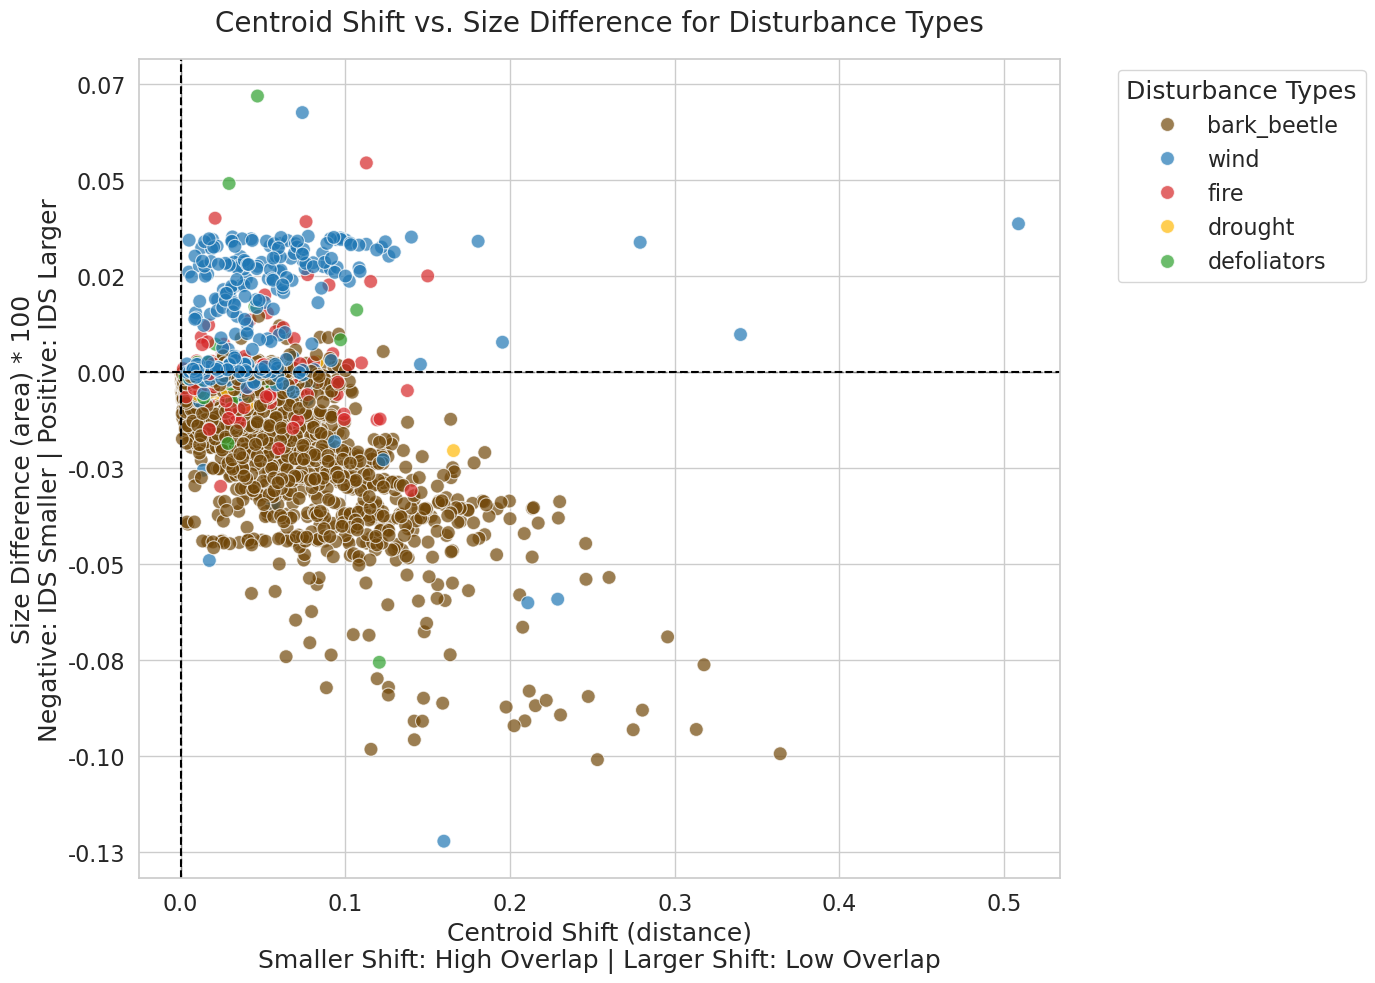

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


# Get the default colors from 'tab10' palette for the rest of the disturbance types
default_palette = sns.color_palette('tab10', n_colors=10)
default_colors = [color for color in default_palette if color not in custom_colors.values()]

# Combine the custom colors with the default colors
custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in result_gdf['DCA_ID'].unique()]

# Multiply 'size_difference' by 100
result_gdf['size_difference_scaled'] = result_gdf['size_difference'] * 100
result_gdf['centroid_shift_scaled'] = result_gdf['centroid_shift'] * 10
# Set Seaborn style
sns.set(style="whitegrid")

# Plot the results with the custom palette
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=result_gdf,
    x='centroid_shift_scaled',
    y='size_difference_scaled',
    hue='DCA_ID',
    palette=custom_palette,
    s=100,
    edgecolor='w',
    alpha=0.7
)

# Customize the plot
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', fontsize=18)
plt.ylabel('Size Difference (area) * 100\nNegative: IDS Smaller | Positive: IDS Larger', fontsize=18)
plt.title('Centroid Shift vs. Size Difference for Disturbance Types', fontsize=20, pad=20)
legend = plt.legend(title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

# Set decimal tick labels
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Increase tick label size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Show quadrant lines
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()


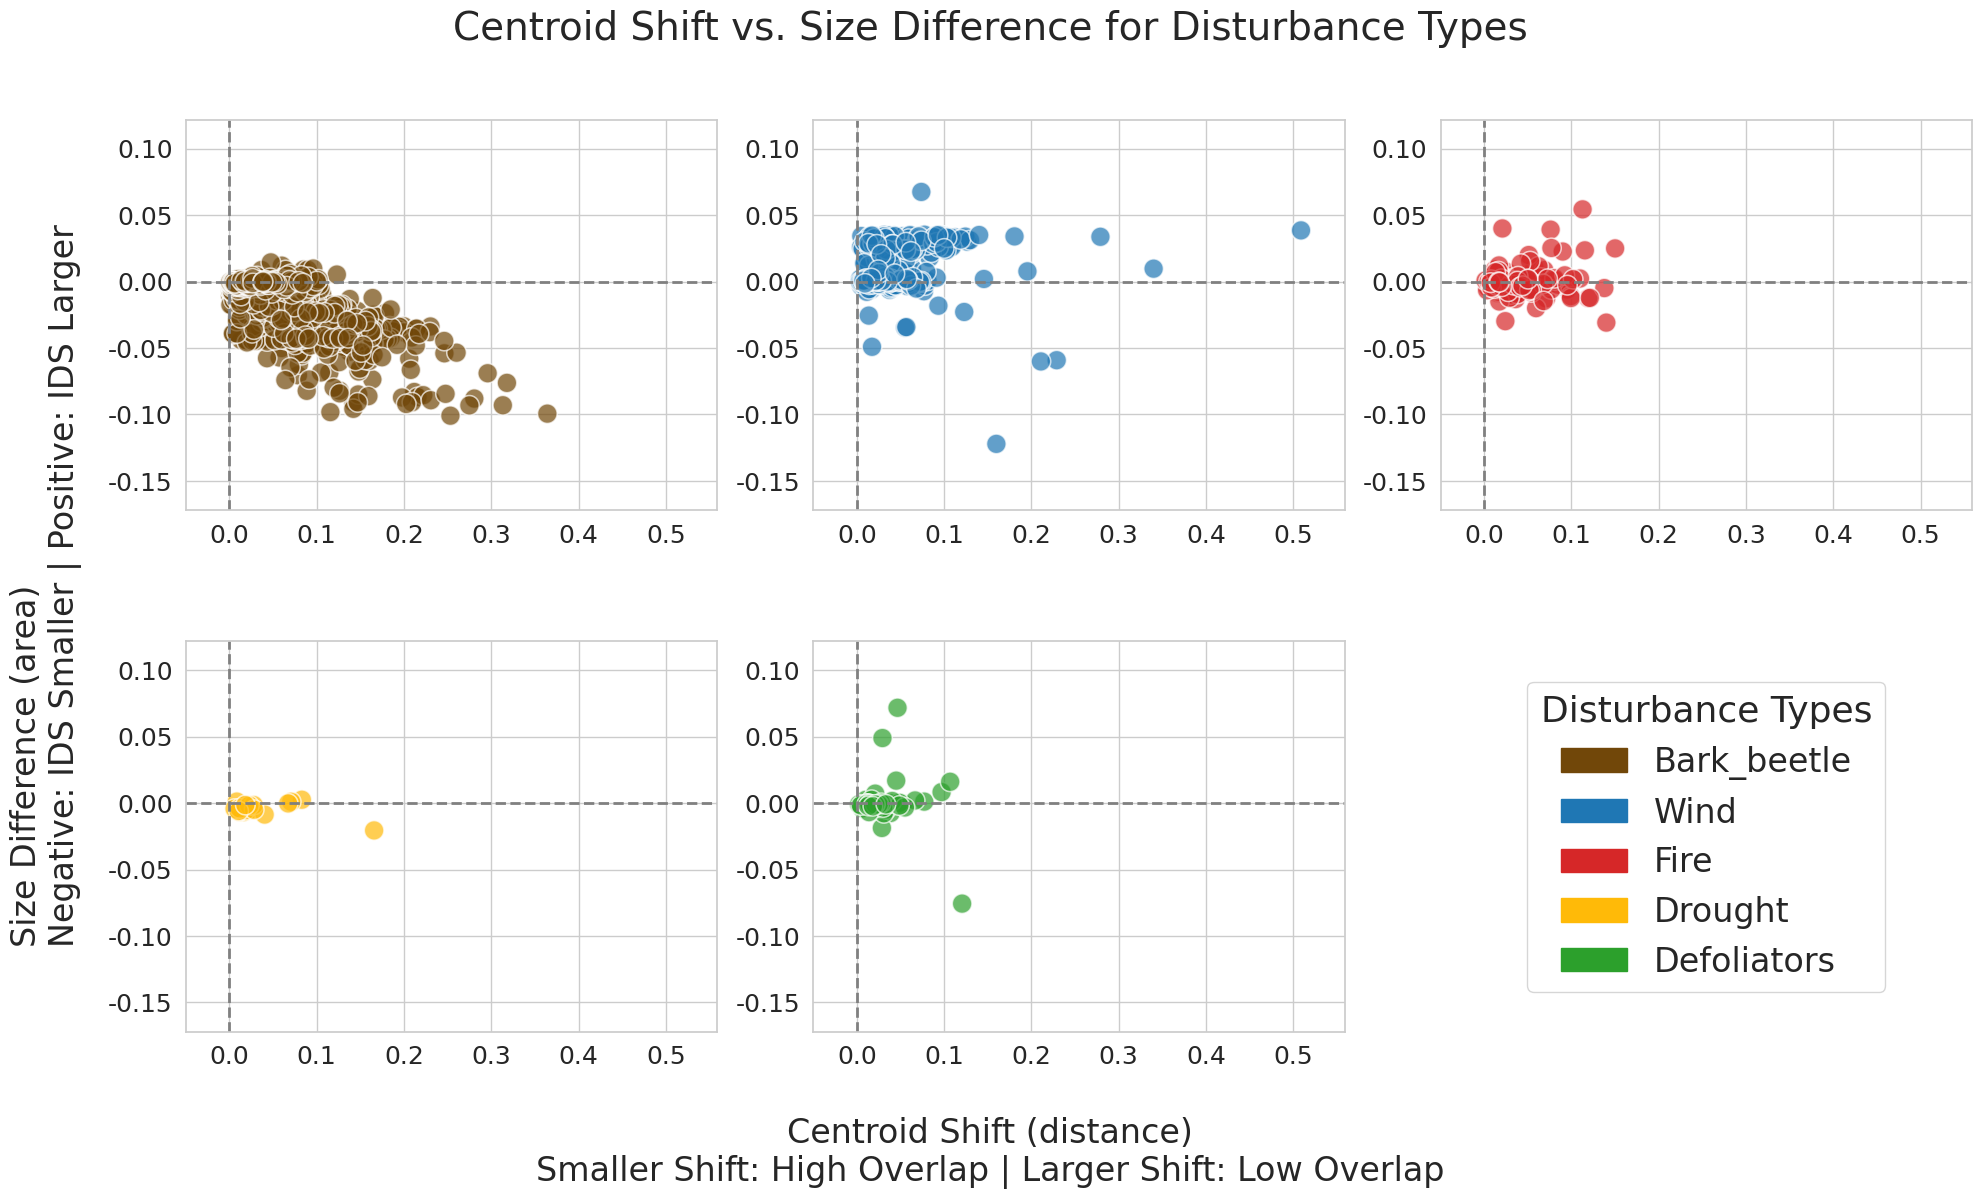

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as mpatches  # Import for custom legend


def plot_scatterplot_size_shift_per_disturbances(gdf, save_dir):

    # Define the order of the categories
    category_order = ['bark_beetle', 'wind', 'fire', 'drought', 'defoliators']

    # Get the default colors from 'tab10' palette for the rest of the disturbance types
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = {label: custom_colors.get(label, default_colors.pop(0)) for label in category_order}

    # Multiply 'size_difference' by 100
    gdf['size_difference_scaled'] = gdf['size_difference'] * 100
    gdf['centroid_shift_scaled'] = gdf['centroid_shift'] * 10

    # Set Seaborn style
    sns.set(style="whitegrid")

    # Create a grid with 3 columns and 2 rows for the plots and legend
    fig, axs = plt.subplots(2, 3, figsize=(20, 12), gridspec_kw={'width_ratios': [1, 1, 1]})

    # Flatten the axes array for easier indexing
    axs = axs.flatten()

    # Plot the scatterplots
    for i, category in enumerate(category_order):
        ax = axs[i]
        sns.scatterplot(
            data=gdf[gdf['DCA_ID'] == category],
            x='centroid_shift_scaled',
            y='size_difference_scaled',
            hue='DCA_ID',
            palette=custom_palette,
            s=200,
            edgecolor='w',
            alpha=0.7,
            ax=ax,
            legend=False  # Disable legend in each subplot
        )
        ax.axhline(0, color='grey', linestyle='--', linewidth=2)
        ax.axvline(0, color='grey', linestyle='--', linewidth=2)
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=18)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.set_xlim(gdf['centroid_shift_scaled'].min() - 0.05, gdf['centroid_shift_scaled'].max() + 0.05)
        ax.set_ylim(gdf['size_difference_scaled'].min() - 0.05, gdf['size_difference_scaled'].max() + 0.05)
        #ax.set_title(category.capitalize(), fontsize=24)
        
        ax.set_ylabel('')

        ax.set_xlabel('')

    # Remove the unused last subplot (bottom right corner)
    fig.delaxes(axs[-1])

    # Add a custom legend to the last subplot
    legend_patches = [mpatches.Patch(color=color, label=label.capitalize()) for label, color in custom_palette.items()]
    legend_ax = fig.add_subplot(2, 3, 6)
    legend_ax.legend(handles=legend_patches, title='Disturbance Types', loc='center', fontsize=24, title_fontsize=26)
    legend_ax.axis('off')

    # Set shared x and y labels
    fig.text(0.5, 0.004, 'Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', ha='center', fontsize=24)
    fig.text(0.01, 0.5, 'Size Difference (area)\nNegative: IDS Smaller | Positive: IDS Larger', va='center', rotation='vertical', fontsize=24)

    # Set the overall title and adjust layout
    plt.subplots_adjust(top=0.4)
    fig.suptitle('Centroid Shift vs. Size Difference for Disturbance Types', fontsize=28)
    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])

    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'size_shift_comparison_scatterplots.png'), bbox_inches='tight')
    plt.show()


plot_scatterplot_size_shift_per_disturbances(result_gdf, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/")


/tmp/ipykernel_725349/914271584.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='centroid_shift_scaled', y='DCA_ID', data=result_gdf, palette=custom_palette, ax=ax, bw=0.2, cut=0)
/tmp/ipykernel_725349/914271584.py:20: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(x='centroid_shift_scaled', y='DCA_ID', data=result_gdf, palette=custom_palette, ax=ax, bw=0.2, cut=0)
/tmp/ipykernel_725349/914271584.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='size_difference_scaled', y='DCA_ID'

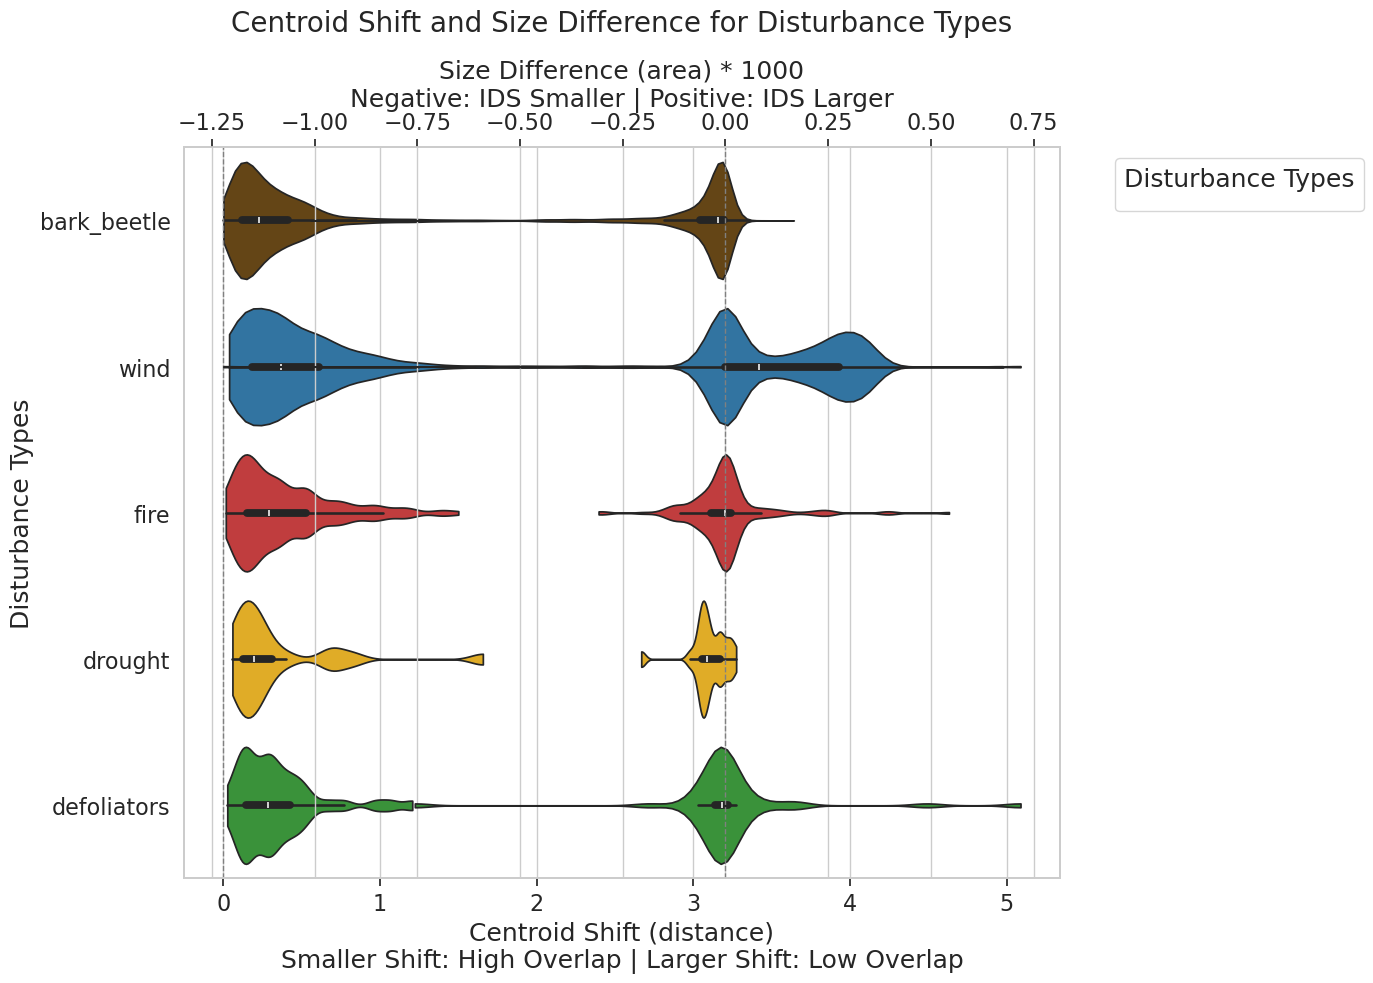

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Multiply 'size_difference' by 1000
result_gdf['size_difference_scaled'] = result_gdf['size_difference'] * 1000
# Multiply 'centroid_shift' by 100
result_gdf['centroid_shift_scaled'] = result_gdf['centroid_shift'] * 100

# Set Seaborn style
sns.set(style="whitegrid")

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(14, 10))

# Custom colors for the plot
custom_palette = {label: custom_colors.get(label, 'grey') for label in result_gdf['DCA_ID'].unique()}

# Plot violin plot for centroid shift
sns.violinplot(x='centroid_shift_scaled', y='DCA_ID', data=result_gdf, palette=custom_palette, ax=ax, bw=0.2, cut=0)
ax.axvline(0, color='grey', linestyle='--', linewidth=1)
ax.set_title('Centroid Shift and Size Difference for Disturbance Types', fontsize=20, pad=20)
ax.set_xlabel('Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', fontsize=18)
ax.set_ylabel('Disturbance Types', fontsize=18)
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)

# Add a second x-axis for size difference
ax2 = ax.twiny()

# Plot violin plot for size difference
sns.violinplot(x='size_difference_scaled', y='DCA_ID', data=result_gdf, palette=custom_palette, ax=ax2, bw=0.2, cut=0)
ax2.axvline(0, color='grey', linestyle='--', linewidth=1)
ax2.set_xlabel('Size Difference (area) * 1000\nNegative: IDS Smaller | Positive: IDS Larger', fontsize=18)
ax2.tick_params(axis='x', labelsize=16)

# Combine the legends
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2
by_label = dict(zip(labels, handles))
legend = ax.legend(by_label.values(), by_label.keys(), title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
legend.set_title('Disturbance Types', prop={'size': 18})

# Increase space between subplots
plt.subplots_adjust(hspace=0.3)

# Set tight layout
plt.tight_layout()

# Show the plot
plt.show()


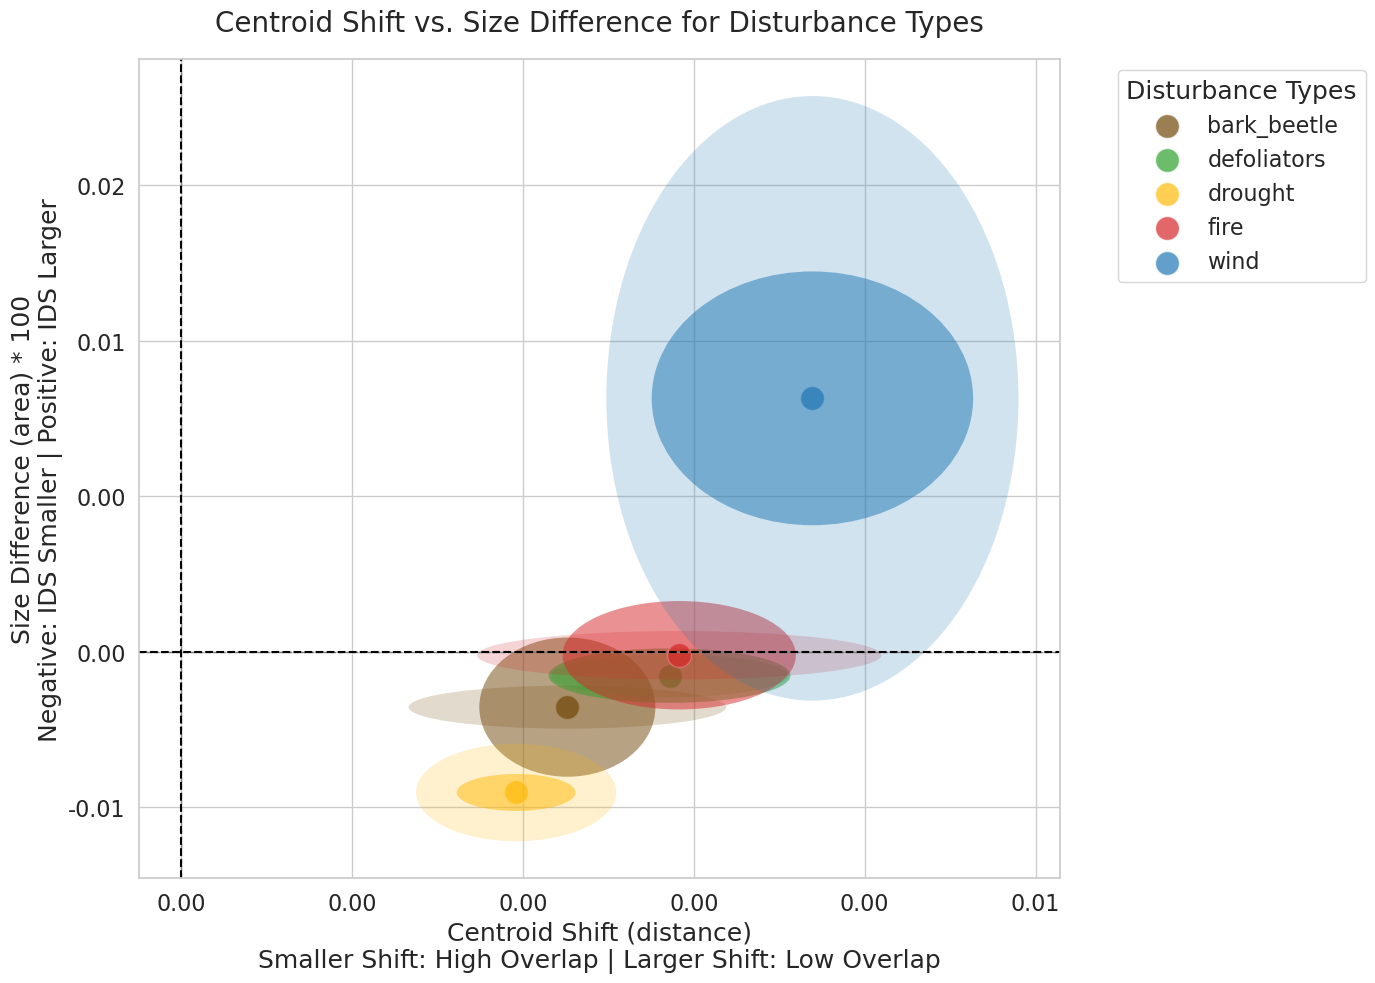

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.patches as patches
import matplotlib.colors as mcolors


# Get the default colors from 'tab10' palette for the rest of the disturbance types
default_palette = sns.color_palette('tab10', n_colors=10)
default_colors = [color for color in default_palette if color not in custom_colors.values()]

# Combine the custom colors with the default colors
custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in result_gdf['DCA_ID'].unique()]

# Multiply 'size_difference' by 100
result_gdf['size_difference_scaled'] = result_gdf['size_difference'] * 100

# Calculate medians and quantiles for each disturbance type
grouped = result_gdf.groupby('DCA_ID').agg({
    'centroid_shift': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
    'size_difference_scaled': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)]
}).reset_index()

# Flatten the column names after aggregation
grouped.columns = ['DCA_ID', 'centroid_shift_median', 'centroid_shift_q25', 'centroid_shift_q75', 'size_diff_median', 'size_diff_q25', 'size_diff_q75']

# Set Seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(14, 10))

# Plot the median values and IQR
for i, row in grouped.iterrows():
    # Plot the median value as a scatter point
    plt.scatter(
        row['centroid_shift_median'],
        row['size_diff_median'],
        color=custom_colors.get(row['DCA_ID'], 'grey'),
        s=300,
        edgecolor='w',
        alpha=0.7,
        label=row['DCA_ID']
    )

    # Draw ellipses for the 25th and 75th percentiles
    width_25 = (row['centroid_shift_median'] - row['centroid_shift_q25'])
    height_25 = (row['size_diff_median'] - row['size_diff_q25'])
    width_75 = (row['centroid_shift_q75'] - row['centroid_shift_median'])
    height_75 = (row['size_diff_q75'] - row['size_diff_median'])

    ellipse_25 = patches.Ellipse(
        (row['centroid_shift_median'], row['size_diff_median']),
        width_25,
        height_25,
        edgecolor='none',  # No edge color for filled ellipse
        facecolor=mcolors.to_rgba(custom_colors.get(row['DCA_ID'], 'grey'), alpha=0.5),
        alpha=0.5
    )

    ellipse_75 = patches.Ellipse(
        (row['centroid_shift_median'], row['size_diff_median']),
        width_75,
        height_75,
        edgecolor='none',  # No edge color for filled ellipse
        facecolor=mcolors.to_rgba(custom_colors.get(row['DCA_ID'], 'grey'), alpha=0.2),
        alpha=0.2
    )

    plt.gca().add_patch(ellipse_25)
    plt.gca().add_patch(ellipse_75)

# Customize the plot
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', fontsize=18)
plt.ylabel('Size Difference (area) * 100\nNegative: IDS Smaller | Positive: IDS Larger', fontsize=18)
plt.title('Centroid Shift vs. Size Difference for Disturbance Types', fontsize=20, pad=20)

# Set legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
legend = plt.legend(by_label.values(), by_label.keys(), title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

# Set decimal tick labels
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Increase tick label size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Show quadrant lines
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()


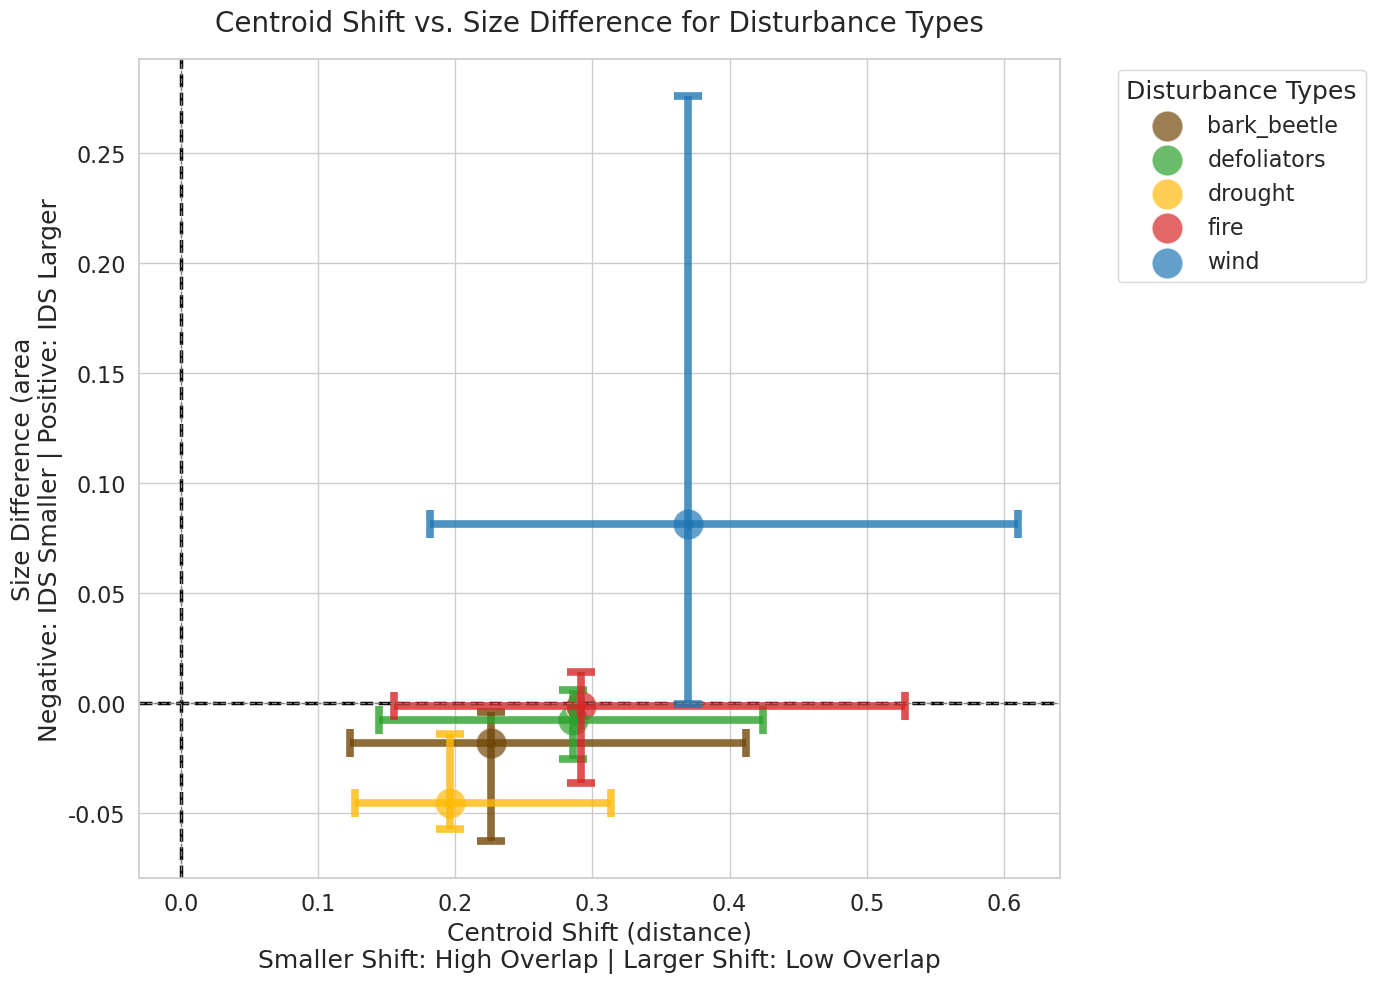

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

def plot_size_shift_comparison_errorbars(gdf, save_dir):

    # Get the default colors from 'tab10' palette for the rest of the disturbance types
    default_palette = sns.color_palette('tab10', n_colors=10)
    default_colors = [color for color in default_palette if color not in custom_colors.values()]

    # Combine the custom colors with the default colors
    custom_palette = [custom_colors.get(label, default_colors.pop(0)) for label in gdf['DCA_ID'].unique()]

    # Multiply 'size_difference' by 100
    gdf['size_difference_scaled'] = gdf['size_difference'] * 1000
    # Multiply 'centroid_shift' by 100
    gdf['centroid_shift_scaled'] = gdf['centroid_shift'] * 100

    # Calculate medians and quantiles for each disturbance type
    grouped = gdf.groupby('DCA_ID').agg({
        'centroid_shift_scaled': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)],
        'size_difference_scaled': ['median', lambda x: np.percentile(x, 25), lambda x: np.percentile(x, 75)]
    }).reset_index()

    # Flatten the column names after aggregation
    grouped.columns = ['DCA_ID', 'centroid_shift_median', 'centroid_shift_q25', 'centroid_shift_q75', 'size_diff_median', 'size_diff_q25', 'size_diff_q75']

    # Set Seaborn style
    sns.set(style="whitegrid")

    plt.figure(figsize=(14,10))

    # Show quadrant lines
    plt.axhline(0, color='black', linewidth=2.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=2.5, linestyle='--')


    # Plot the median values and IQR with shaded regions
    for i, row in grouped.iterrows():
        plt.scatter(
            row['centroid_shift_median'],
            row['size_diff_median'],
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            s=500,  # Larger scatter points
            edgecolor='w',
            alpha=0.7,
            label=row['DCA_ID']
        )
        plt.errorbar(
            row['centroid_shift_median'],
            row['size_diff_median'],
            xerr=[[row['centroid_shift_median'] - row['centroid_shift_q25']], [row['centroid_shift_q75'] - row['centroid_shift_median']]],
            yerr=[[row['size_diff_median'] - row['size_diff_q25']], [row['size_diff_q75'] - row['size_diff_median']]],
            fmt='o',
            color=custom_colors.get(row['DCA_ID'], 'grey'),
            alpha=0.8,
            capsize=10,  # Larger error bar caps
            capthick=5.5,
            linewidth=5.5  # Thicker error bar lines
        )

    # Customize the plot
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Centroid Shift (distance)\nSmaller Shift: High Overlap | Larger Shift: Low Overlap', fontsize=18)
    plt.ylabel('Size Difference (area\nNegative: IDS Smaller | Positive: IDS Larger', fontsize=18)
    plt.title('Centroid Shift vs. Size Difference for Disturbance Types', fontsize=20, pad=20)

    # Set legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    legend = plt.legend(by_label.values(), by_label.keys(), title='Disturbance Types', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)
    legend.set_title('Disturbance Types', prop={'size': 18})  # Set legend title size

    # Set decimal tick labels
    plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    # Increase tick label size
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.tight_layout()
    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'size_shift_comparison_errorbars.png'), bbox_inches='tight')
    plt.show()


plot_size_shift_comparison_errorbars(result_gdf, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/")

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def plot_length_of_disturbance_events(refdm_dataset, save_dir):

    dca_ids = refdm_dataset['DCA_ID'].unique()

    # Function to create shades of a color
    def create_shades(color, n):
        base_color = np.array(mcolors.to_rgb(color))
        return [mcolors.to_hex(base_color * (1 - 0.2 * i)) for i in range(n)]

    # Define the width of each bar
    bar_width = 0.2

    # Extract unique DCA_IDs from the dataset
    dca_ids = refdm_dataset['DCA_ID'].unique()

    # Create subplots for each DCA_ID
    fig, axs = plt.subplots(1, len(dca_ids), figsize=(20, 4), sharex=True)

    # Iterate over each DCA_ID
    for i, dca_id in enumerate(dca_ids):
        # Filter refdm_dataset for the current DCA_ID
        dca_data = refdm_dataset[refdm_dataset['DCA_ID'] == dca_id]
        
        # Group the data by USDA_IDX and count occurrences
        usda_idx_counts = dca_data.groupby('USDA_IDX').size()
        
        # Count occurrences of USDA_IDX with 1, 2, or 3 instances
        usda_idx_1_instance = sum(usda_idx_counts == 1)
        usda_idx_2_instances = sum(usda_idx_counts == 2)
        usda_idx_3_instances = sum(usda_idx_counts == 3)
        
        # Calculate the x positions for the bars
        x = np.arange(3)
        
        # Get the color shades for the current DCA_ID
        shades = create_shades(custom_colors.get(dca_id, '#000000'), 3)
        
        # Plot the bars for each year
        axs[i].bar(x - bar_width, [usda_idx_1_instance, 0, 0], width=bar_width, label='1 Year', color=shades[0])
        axs[i].bar(x, [0, usda_idx_2_instances, 0], width=bar_width, label='2 Years', color=shades[1])
        axs[i].bar(x + bar_width, [0, 0, usda_idx_3_instances], width=bar_width, label='3 Years', color=shades[2])
        
        # Set plot title and y-axis label with larger font sizes
        axs[i].set_title(f'{dca_id.capitalize()}', fontsize=16)
        axs[i].set_ylabel('Number of Events', fontsize=16)
        axs[i].set_xticks(x)
        axs[i].tick_params(axis='x', labelsize=16, rotation=45)
        axs[i].tick_params(axis='y', labelsize=16)
        axs[i].legend(fontsize=14)
        
        # Set x-tick labels separately to avoid FixedFormatter warning
        axs[i].set_xticklabels(['1 Year', '2 Years', '3 Years'])

    # Set common x-axis label with larger font size
    fig.text(0.5, -0.05, 'Number of Appearances', ha='center', fontsize=18)
    fig.tight_layout()

    # Show the plot
    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'refdm_length_of_disturbance_events.png'), bbox_inches='tight')

    plt.show()


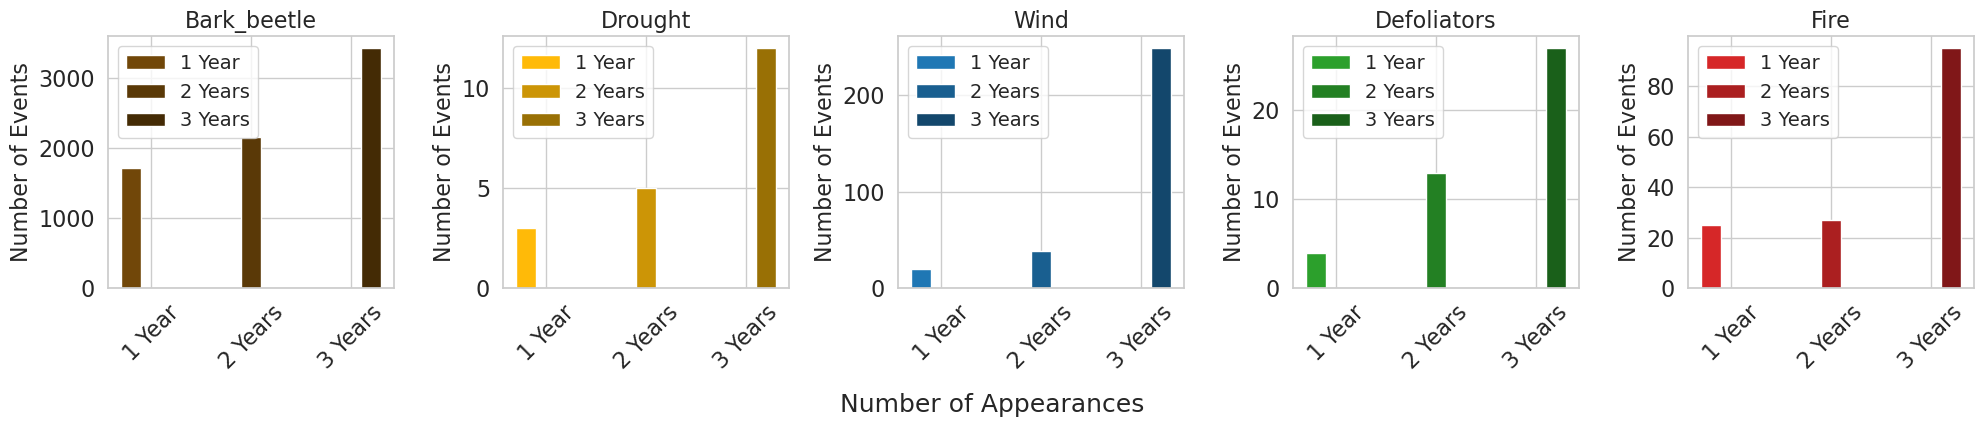

In [24]:
plot_length_of_disturbance_events(refdm_dataset, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/")

/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1466708/2779377851.py:45: Fut

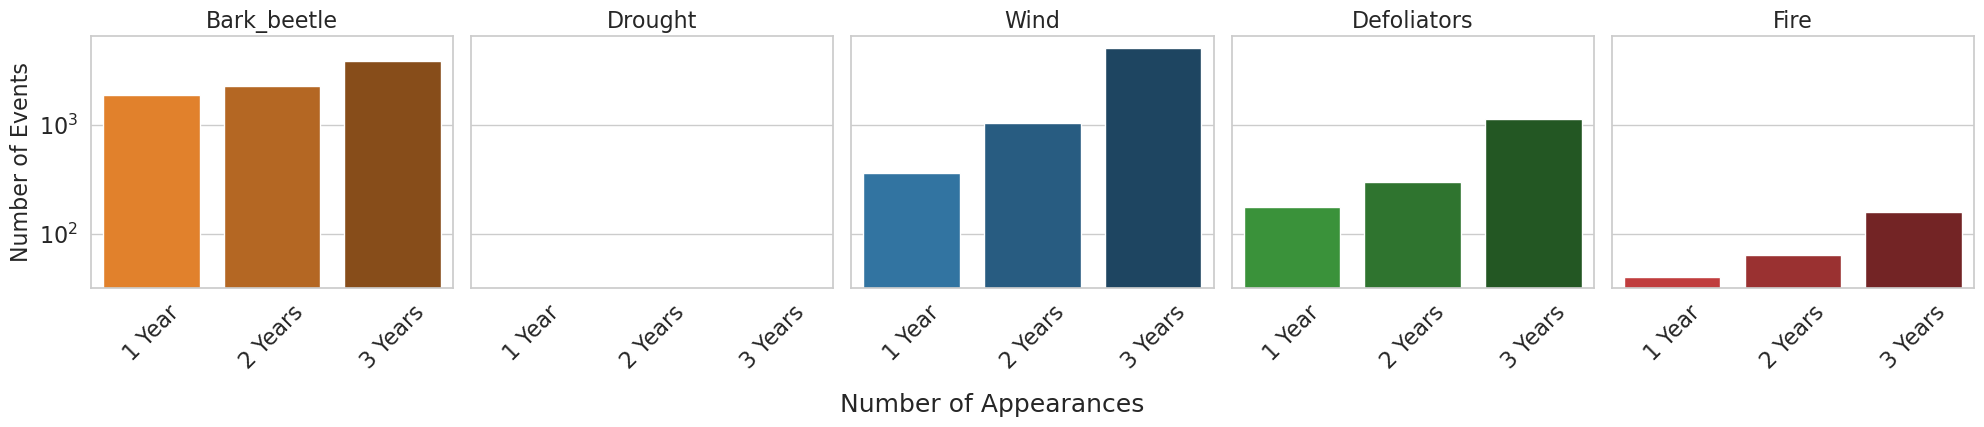

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# Define specific colors for each disturbance type
custom_colors = {
    'wind': '#1f77b4',      # tab:blue
    'fire': '#d62728',      # tab:red
    'defoliators': '#2ca02c',  # tab:green
    'drought': '#9467bd',   # tab:purple
    'bark_beetle': '#ff7f0e'  # tab:orange
}

# Function to create shades of a color
def create_shades(color, n):
    base_color = np.array(mcolors.to_rgb(color))
    return [mcolors.to_hex(base_color * (1 - 0.2 * i)) for i in range(n)]

# Extract unique DCA_IDs from the dataset
dca_ids = refdm_dataset['DCA_ID'].unique()

# Create a long format dataframe for seaborn
plot_data = []
for dca_id in dca_ids:
    dca_data = refdm_dataset[refdm_dataset['DCA_ID'] == dca_id]
    usda_idx_counts = dca_data.groupby('USDA_IDX').size()
    usda_idx_1_instance = sum(usda_idx_counts == 1)
    usda_idx_2_instances = sum(usda_idx_counts == 2)
    usda_idx_3_instances = sum(usda_idx_counts == 3)
    
    plot_data.append({'DCA_ID': dca_id, 'Years': '1 Year', 'Count': usda_idx_1_instance})
    plot_data.append({'DCA_ID': dca_id, 'Years': '2 Years', 'Count': usda_idx_2_instances})
    plot_data.append({'DCA_ID': dca_id, 'Years': '3 Years', 'Count': usda_idx_3_instances})

plot_df = pd.DataFrame(plot_data)

# Create subplots for each DCA_ID
fig, axs = plt.subplots(1, len(dca_ids), figsize=(20, 4), sharex=True, sharey=True)

# Iterate over each DCA_ID to create individual bar plots
for i, dca_id in enumerate(dca_ids):
    ax = axs[i]
    sns.barplot(
        data=plot_df[plot_df['DCA_ID'] == dca_id],
        x='Years', y='Count', ax=ax,
        palette=create_shades(custom_colors.get(dca_id, '#000000'), 3)
    )
    ax.set_yscale('log')
    ax.set_title(f'{dca_id.capitalize()}', fontsize=16)
    ax.set_xlabel('')
    ax.set_ylabel('Number of Events' if i == 0 else '', fontsize=16)
    ax.tick_params(axis='x', labelsize=16, rotation=45)
    ax.tick_params(axis='y', labelsize=16)

# Set common x-axis label with larger font size
fig.text(0.5, -0.05, 'Number of Appearances', ha='center', fontsize=18)
fig.tight_layout()

# Show the plot
plt.show()

# Merging of the years if there is a big enough overlapp

In [17]:
# Define the path to your shapefile
refdm_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/radar_enhanced_forest_disturbance_mapping.shp"

# Load the shapefile using geopandas
refdm_dataset = gpd.read_file(refdm_path)

# Optionally, display the CRS (Coordinate Reference System)
print("CRS:", refdm_dataset.crs)
print("Amount of Events in the Radar-Enhanced-Forest-Disturbance-Mapping Dataset:", len(refdm_dataset))

refdm_dataset.head()

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Amount of Events in the Radar-Enhanced-Forest-Disturbance-Mapping Dataset: 41776


,USDA_IDX,S1_YEAR,S1_TILE,S1CD_IDX,DCA_ID,SURV_YEAR,REG_ID,DAM_TYPE,DAM_TYPE_C,DCA_CD,DA_CD_USDA,PCT_AFFECT,HOST,HOST_CODE,cluster_id,area_degre,area_meter,square_km,geometry
0,bark_beetle_2019_12801,2020,E084N024T3,12801,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000026,295662.269883,0.295662,"MULTIPOLYGON (((-94.92155 31.15303, -94.92078 ..."
1,bark_beetle_2019_12802,2020,E084N024T3,12802,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000009,102406.849951,0.102407,"MULTIPOLYGON (((-94.92386 31.15708, -94.92367 ..."
2,bark_beetle_2019_12803,2020,E084N024T3,12803,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000021,238655.338758,0.238655,"MULTIPOLYGON (((-94.91769 31.15149, -94.91750 ..."
3,bark_beetle_2019_12804,2020,E084N024T3,12804,bark_beetle,2019,8,Mortality,2,11030,1,Light (4-10%),None,None,12360,0.000018,207787.019607,0.207787,"MULTIPOLYGON (((-94.91558 31.15554, -94.91558 ..."
4,bark_beetle_2019_12805,2020,E084N024T3,12805,bark_beetle,2019,8,Mortality,2,11030,1,Very Light (1-3%),None,None,18275,0.000044,510175.284005,0.510175,"MULTIPOLYGON (((-94.90383 31.16151, -94.90325 ..."


In [178]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

def calculate_geometry_overlap_score(dataset):
    """
    Calculate overlap scores and merge geometries with more than 70% overlap,
    storing their S1_YEAR values in a list.

    Parameters:
    dataset (GeoDataFrame): The input dataset with 'USDA_IDX' and 'geometry' columns.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged geometries and their S1_YEAR values.
    """
    # Lists to hold merged and singular geometries
    merged_data = []
    singular_data = []

    # Iterate over unique USDA_IDX values
    for usda_idx in dataset['USDA_IDX'].unique():
        group = dataset[dataset['USDA_IDX'] == usda_idx]
        if len(group) == 1:
            singular_data.append(group)  # Add single entry groups to singular_data
        else:
            merged_geom = unary_union(group.geometry)  # Merge geometries
            s1_years = group['S1_YEAR'].tolist()  # List of S1_YEARs
            dca_id = group['DCA_ID'].tolist()  # List of DCA_IDs
            best_year = group.loc[group.geometry.area.idxmax()]['S1_YEAR']  # Best year by largest area

            # Append merged data
            merged_data.append({
                'USDA_IDX': usda_idx,
                'geometry': merged_geom,
                'S1_YEARs': s1_years,
                'best_year': best_year,
                'DCA_ID': dca_id
            })

    # Convert lists to GeoDataFrames
    merged_gdf = gpd.GeoDataFrame(merged_data)
    unmerged_gdf = pd.concat(singular_data, ignore_index=True) if singular_data else gpd.GeoDataFrame(columns=dataset.columns, crs=dataset.crs)

    # Concatenate GeoDataFrames
    concatenated_gdf = pd.concat([unmerged_gdf, merged_gdf], ignore_index=True)

    # Ensure CRS consistency
    concatenated_gdf = gpd.GeoDataFrame(concatenated_gdf, crs=merged_gdf.crs)

    # Keep specific columns and merge year columns
    columns_to_keep = ['USDA_IDX', 'geometry', 'S1_YEARs', 'best_year', 'S1_YEAR']
    concatenated_gdf = concatenated_gdf[columns_to_keep]
    concatenated_gdf['year_refdm'] = concatenated_gdf['best_year'].combine_first(concatenated_gdf['S1_YEAR'])

    # Drop the original year columns and return the final GeoDataFrame
    return concatenated_gdf.drop(columns=['best_year', 'S1_YEAR'])


In [182]:
import geopandas as gpd
import pandas as pd
from shapely.ops import unary_union

def calculate_dissolved_geometries_year(dataset):
    """
    Merge geometries and storetheir S1_YEAR values in a list.

    Parameters:
    dataset (GeoDataFrame): The input dataset with 'USDA_IDX' and 'geometry' columns.

    Returns:
    GeoDataFrame: A GeoDataFrame with merged geometries and their S1_YEAR values.
    """
    # Lists to hold merged and singular geometries
    merged_data = []
    singular_data = []

    # Iterate over unique USDA_IDX values
    for usda_idx in dataset['USDA_IDX'].unique():
        group = dataset[dataset['USDA_IDX'] == usda_idx]
        if len(group) == 1:
            singular_data.append(group)  # Add single entry groups to singular_data
        else:
            merged_geom = unary_union(group.geometry)  # Merge geometries
            s1_years = group['S1_YEAR'].tolist()  # List of S1_YEARs
            dca_id = group['DCA_ID'].tolist()  # List of DCA_IDs
            best_year = group.loc[group.geometry.area.idxmax()]['S1_YEAR']  # Best year by largest area

            # Append merged data
            merged_data.append({
                'USDA_IDX': usda_idx,
                'geometry': merged_geom,
                'S1_YEARs': s1_years,
                'best_year': best_year,
                'DCA_ID': dca_id
            })

    # Convert lists to GeoDataFrames
    merged_gdf = gpd.GeoDataFrame(merged_data)
    unmerged_gdf = pd.concat(singular_data, ignore_index=True) if singular_data else gpd.GeoDataFrame(columns=dataset.columns, crs=dataset.crs)

    # Concatenate GeoDataFrames
    concatenated_gdf = pd.concat([unmerged_gdf, merged_gdf], ignore_index=True)

    # Ensure CRS consistency
    concatenated_gdf = gpd.GeoDataFrame(concatenated_gdf, crs=merged_gdf.crs)

    # Keep specific columns and merge year columns
    columns_to_keep = ['USDA_IDX', 'geometry', 'S1_YEARs', 'best_year', 'S1_YEAR']
    concatenated_gdf = concatenated_gdf[columns_to_keep]
    concatenated_gdf['year_refdm'] = concatenated_gdf['best_year'].combine_first(concatenated_gdf['S1_YEAR'])

    # Drop the original year columns and return the final GeoDataFrame
    return concatenated_gdf.drop(columns=['best_year', 'S1_YEAR'])


In [181]:
dissolved_geometries_year = calculate_dissolved_geometries_year(refdm_dataset)
print(f"Events: {len(dissolved_geometries_year)}")
dissolved_geometries_year

NameError: name 'calculate_dissolved_geometries_year' is not defined

In [179]:
merged_gdf = calculate_geometry_overlap_score(refdm_dataset)
print(f"Events: {len(merged_gdf)}")
merged_gdf

/tmp/ipykernel_627997/4184389039.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  best_row = group.loc[group.geometry.area.idxmax()]
/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/geopandas/array.py:1486: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  warnings.warn(


Events: 16754


,USDA_IDX,geometry,S1_YEARs,year_refdm
0,bark_beetle_2019_12802,"MULTIPOLYGON (((-94.92386 31.15708, -94.92367 ...",NaN,2020
1,bark_beetle_2019_12804,"MULTIPOLYGON (((-94.91558 31.15554, -94.91558 ...",NaN,2020
2,wind_2020_13102,"POLYGON ((-93.22208 30.86314, -93.22189 30.863...",NaN,2020
3,wind_2020_13110,"POLYGON ((-93.20648 30.89493, -93.20629 30.894...",NaN,2020
4,wind_2020_13139,"MULTIPOLYGON (((-93.19242 30.89204, -93.19281 ...",NaN,2020
...,...,...,...,...
16749,bark_beetle_2018_9846,"MULTIPOLYGON (((-89.64521 32.13072, -89.64521 ...","[2017, 2018]",2018
16750,bark_beetle_2018_9995,"MULTIPOLYGON (((-89.58923 32.10264, -89.58942 ...","[2017, 2018]",2017
16751,bark_beetle_2018_9996,"MULTIPOLYGON (((-89.63031 32.08430, -89.63012 ...","[2017, 2018]",2017
16752,bark_beetle_2017_2982,"MULTIPOLYGON (((-84.89068 30.61123, -84.89068 ...","[2017, 2018]",2018


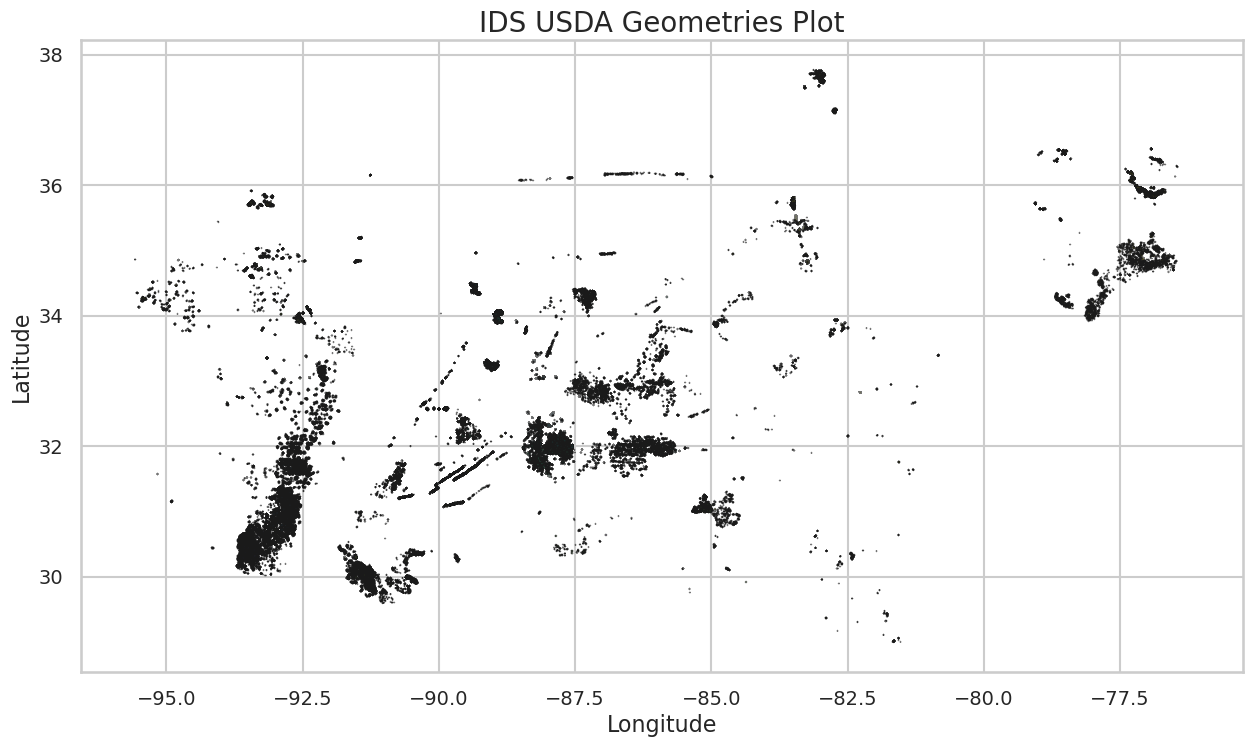

In [180]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up Seaborn's plotting aesthetics
sns.set(style="whitegrid", context="talk")

# Load your GeoDataFrame
# gdf = gpd.read_file("path_to_your_file.shp")  # Uncomment and adjust this line to load your file

# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(15, 15))  # Adjust the figsize as needed

# Plot the GeoDataFrame with GeoPandas
merged_gdf.plot(ax=ax, edgecolor='k', linewidth=1, alpha=0.6, cmap='viridis')  # Adjust plot settings as needed

# Customize the plot
ax.set_title('IDS USDA Geometries Plot', fontsize=20)
ax.set_xlabel('Longitude', fontsize=16)
ax.set_ylabel('Latitude', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True)

# Show the plot
plt.show()


# Compress Tif

In [ ]:
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt

# Paths
forest_map_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/wp1_nlcd_tcc_conus_2017_v2021_4_20m_4326_cropped_region_08.tif"
usa_path = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/data/S_USA.AdministrativeRegion/S_USA.AdministrativeRegion.shp"

# Get Region 8 from the shapefile
def get_region_8(path):

    usa = gpd.read_file(path)
    # Filter for REGION 08
    region_8 = usa[usa['REGION'] == '08']

    # Print to verify
    r8 = region_8.explode(index_parts=True)
    r8.reset_index()
    r8 = r8[0:1]
    r8_union = r8.unary_union
    return r8_union

print("Get Region 8 geometry ...")
# Get Region 8 geometry
r8_geometry = get_region_8(usa_path)

print("Load the forest map TIFF file ...")
# Load the forest map TIFF file
forest_map = rioxarray.open_rasterio(forest_map_path, masked=True).squeeze()

print("Ensure the CRS is EPSG:4326")
# Ensure the CRS is EPSG:4326
forest_map = forest_map.rio.write_crs("EPSG:4326")
print("Coarsen ...")
factor = 10  # Adjust this factor as needed to reduce memory usage
forest_map = forest_map.coarsen(x=factor, y=factor, boundary='trim').mean()

print("Crop the forest map to Region 8")
# Crop the forest map to Region 8
#forest_map_cropped = forest_map.rio.clip([r8_geometry], forest_map.rio.crs, drop=True)
forest_map_cropped = forest_map.rio.clip([r8_geometry], forest_map.rio.crs, drop=True, from_disk=True)



print("Save the cropped result as a NetCDF file ...")
# Save the cropped result as a NetCDF file
cropped_nc_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_region_8_forest_map_complete.nc"
forest_map_cropped.to_netcdf(cropped_nc_path)

print(f"Cropped NetCDF file saved to {cropped_nc_path}")


Get Region 8 geometry ...


Load the forest map TIFF file ...
Ensure the CRS is EPSG:4326
Coarsen ...


ERROR 1: PROJ: internal_proj_create_from_database: /Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


: 

In [5]:
import xarray as xr
import matplotlib.pyplot as plt

# Path to the cropped NetCDF file
cropped_nc_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_region_8_forest_map_complete.nc"

# Load the cropped NetCDF file using xarray
cropped_forest_map = xr.open_dataset(cropped_nc_path)

# Rename the variable from __xarray_dataarray_variable__ to tcc
cropped_forest_map = cropped_forest_map.rename({'__xarray_dataarray_variable__': 'tcc'})

# Remove the spatial_ref variable
cropped_forest_map = cropped_forest_map.drop_vars('spatial_ref')

# Downsample the data for plotting
factor = 10  # Adjust this factor as needed to reduce memory usage
cropped_forest_map_downsampled = cropped_forest_map.coarsen(x=factor, y=factor, boundary='trim').mean()

# Path to the cropped NetCDF file
cropped_nc_output_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_downsampled_region_8_forest_map.nc"
cropped_forest_map_downsampled.to_netcdf(cropped_nc_output_path)
print(f"Cropped NetCDF file saved to {cropped_nc_output_path}")

# Print the dataset information
cropped_forest_map_downsampled


Cropped NetCDF file saved to /Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_downsampled_region_8_forest_map.nc


<xarray.Dataset>
Dimensions:  (y: 660, x: 1423)
Coordinates:
    band     int64 1
  * x        (x) float64 -106.6 -106.6 -106.6 -106.6 ... -75.79 -75.76 -75.74
  * y        (y) float64 39.45 39.43 39.41 39.39 ... 25.2 25.18 25.16 25.14
Data variables:
    tcc      (y, x) float32 nan nan nan nan nan nan ... nan nan nan nan nan nan

In [17]:
# Path to the cropped NetCDF file
cropped_nc_output_path = "/Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_downsampled_region_8_forest_map.nc"
cropped_forest_map_downsampled = xr.open_dataset(cropped_nc_output_path)
print(f"Opend NetCDF file from {cropped_nc_output_path}")
# Print the dataset information
cropped_forest_map_downsampled

Opend NetCDF file from /Net/Groups/BGI/work_2/ForExD/WP1/Data/nlcd_tcc_CONUS_2017_v2021-4/cropped_downsampled_region_8_forest_map.nc


<xarray.Dataset>
Dimensions:  (y: 660, x: 1423)
Coordinates:
  * x        (x) float64 -106.6 -106.6 -106.6 -106.6 ... -75.79 -75.76 -75.74
  * y        (y) float64 39.45 39.43 39.41 39.39 ... 25.2 25.18 25.16 25.14
Data variables:
    tcc      (y, x) float32 ...
    band     int64 ...

/tmp/ipykernel_3108182/2188742623.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Greens')


/tmp/ipykernel_3108182/2188742623.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


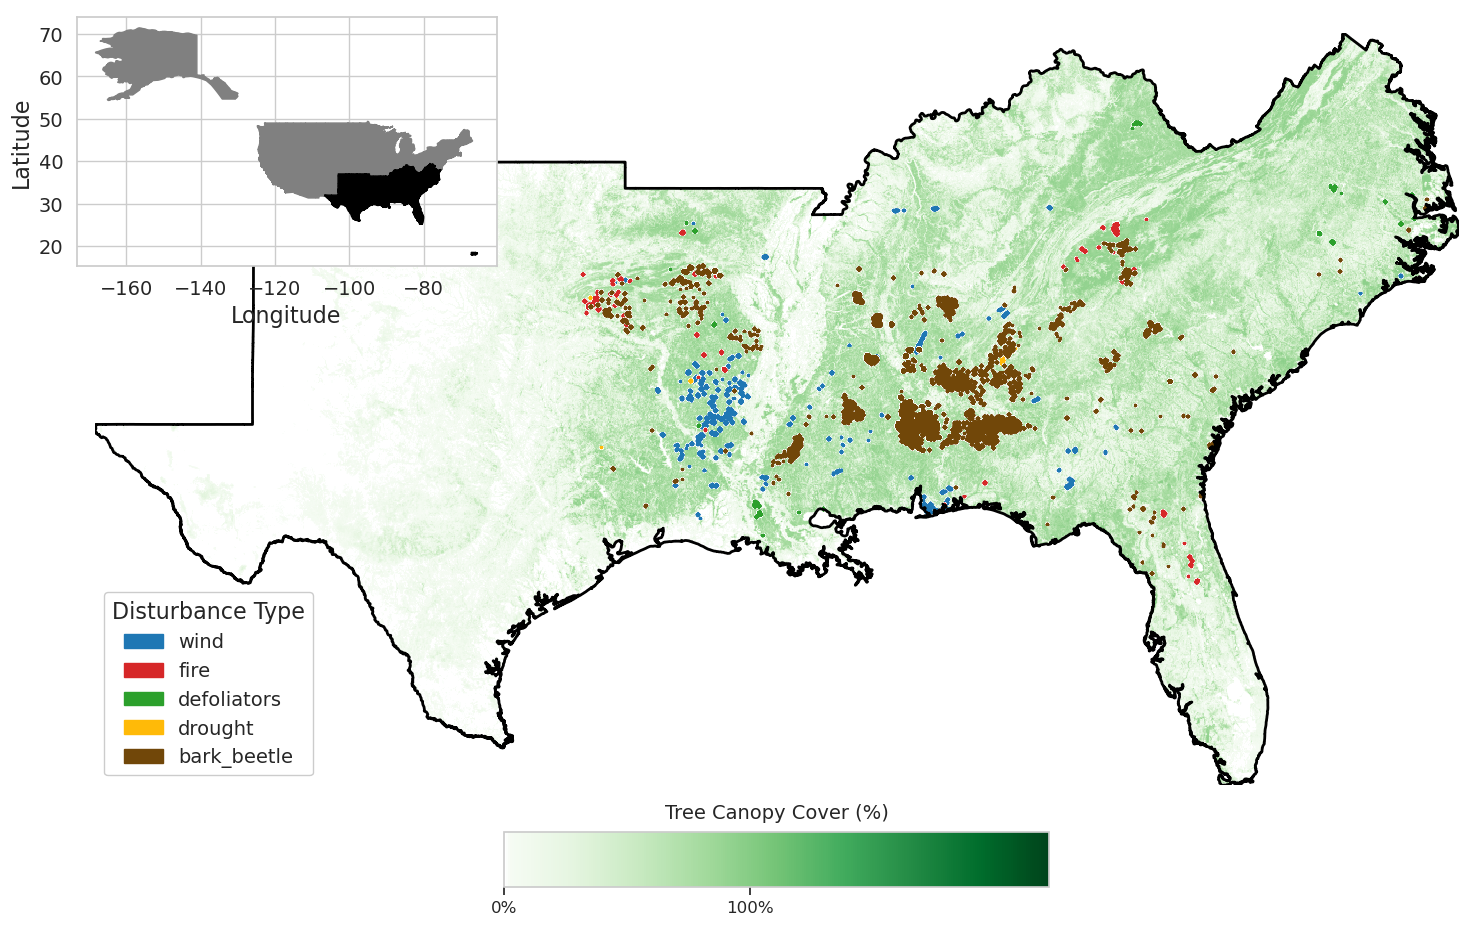

In [19]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_figure_1_2(cropped_forest, usa_mainland, r8, refdm_dissolved, save_dir):

    # Set Seaborn style
    sns.set(style="whitegrid")

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))

    # Plot the entire USA in grey in the upper left corner
    sub_ax = fig.add_axes([0, 0.7, 0.3, 0.3])  # [left, bottom, width, height]
    usa_mainland[usa_mainland['REGION'] != '08'].plot(ax=sub_ax, color='grey', edgecolor='grey')
    usa_mainland[usa_mainland['REGION'] == '08'].plot(ax=sub_ax, color='black', edgecolor='black')

    # Customize the plot
    sub_ax.set_xlabel('Longitude', fontsize=16)
    sub_ax.set_ylabel('Latitude', fontsize=16)
    sub_ax.tick_params(axis='both', which='major', labelsize=14)
    sub_ax.grid(True)
    sub_ax.axis('on')

    #Create a custom colormap
    cmap = plt.cm.get_cmap('Greens')
    new_colors = cmap(np.linspace(0, 1, 100))
    new_colors[0, :] = [1, 1, 1, 1]  # Set the first color (corresponding to 0) to white
    custom_cmap = LinearSegmentedColormap.from_list('CustomGreens', new_colors)

    #cropped_forest['tcc'] = cropped_forest['tcc'].where(cropped_forest['tcc'] <= 110, 0)
    # Plot the downsampled forest map (TCC mask) within Region 8 boundaries
    plot = cropped_forest['tcc'].plot(ax=ax, cmap=custom_cmap , add_colorbar=False) # Create the colorbar for the downsampled map
    cbar = plt.colorbar(plot, ax=ax, orientation='horizontal', pad=0.05, aspect=10, shrink=0.4)
    # Adjust colorbar position
    cbar.ax.set_position([0.42, 0.3, 0.25, 0.03])  # [left, bottom, width, height]
    cbar.set_ticks([0, 100])
    cbar.set_ticklabels(['0%', '100%'])
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label('Tree Canopy Cover (%)', fontsize=12, labelpad=6)
    # Adjust colorbar position and move the label above
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.xaxis.label.set_size(14)
    cbar.ax.xaxis.labelpad = 10

    # Plot Region 8 in the main part of the image
    # Map colors to DCA_IDs
    refdm_dissolved['color'] = refdm_dissolved['DCA_ID'].map(custom_colors)

    # Plot the region outline
    r8.boundary.plot(ax=ax, linewidth=2, color='black')

    # # Plot each disturbance type with its corresponding color
    # for disturbance, color in custom_colors.items():
    #     refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
    #         ax=ax, linewidth=2.5, color=color, edgecolor=color  # Adjust linewidth and edgecolor as needed
    #     )

    # Plot each disturbance type with its corresponding color and white edge
    for disturbance, color in custom_colors.items():
        # First plot with white edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=3.5, color=color, edgecolor='white'
        )
        # Then plot with the actual color and thinner edge
        refdm_dissolved[refdm_dissolved['DCA_ID'] == disturbance].plot(
            ax=ax, linewidth=2.5, color=color, edgecolor=color
        )    

    # Customize the plot
    ax.axis('off')  # Remove axis and frame

    # Ensure the downsampled map fits within Region 8 boundaries
    ax.set_title(' ', fontsize=14)
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True)

    # Set the aspect ratio explicitly to avoid errors
    ax.set_aspect('auto')  # or ax_downsampled.set_aspect('equal')

    # # Create the colorbar for the downsampled map
    # cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='horizontal', pad=0.05, aspect=40, shrink=0.6)
    # cbar.set_ticks([0, 100])
    # cbar.set_ticklabels(['0', '100'])
    # cbar.ax.tick_params(labelsize=10)
    # cbar.set_label('Tree Canopy Cover (%)', fontsize=12, labelpad=10)
    legend_patches = [mpatches.Patch(color=color, label=disturbance) for disturbance, color in custom_colors.items()]
    ax.legend(handles=legend_patches, fontsize=14, title="Disturbance Type", title_fontsize=16, loc='lower left', facecolor='white', framealpha=1)

    # Save the plot
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
    plt.savefig(os.path.join(save_dir, 'figure_1.png'))
    plt.tight_layout()
    plt.show()

plot_figure_1_2(cropped_forest_map_downsampled, usa_mainland, r8, refdm_dissolved, save_dir="/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/figures/")